In [1]:
# Import Libraries untuk Analisis Prophet dengan Optimasi
from prophet import Prophet
from prophet.make_holidays import make_holidays_df
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from itertools import product
import json

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')
plt.style.use('fivethirtyeight')

print("Libraries berhasil dimuat!")
print("Notebook ini akan menampilkan analisis Prophet dengan MAPE yang sudah dioptimasi")

c:\laragon\bin\python\python-3.10\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries berhasil dimuat!
Notebook ini akan menampilkan analisis Prophet dengan MAPE yang sudah dioptimasi


In [2]:
df = pd.read_excel("../data/data_kiriman.xlsx")
df.describe()

,SLA,Kantor_Kirim,Tgl_Kirim,Tgl_Antaran_Pertama,Tgl_Update,Berat,Cek
count,965003.000000,965003.000000,965003,965003,965003,965003.000000,965003.0
mean,2.281931,50826.053391,2023-02-25 02:27:21.960491008,2023-02-27 02:38:10.271844352,2023-02-27 03:56:00.154941440,0.569269,1.0
min,2.000000,10000.000000,2020-12-26 00:00:00,2021-01-01 00:00:00,2021-01-01 00:00:00,0.010000,1.0
25%,2.000000,40000.000000,2022-04-03 00:00:00,2022-04-05 00:00:00,2022-04-05 00:00:00,0.020000,1.0
50%,2.000000,61300.000000,2023-02-27 00:00:00,2023-02-28 00:00:00,2023-02-28 00:00:00,0.100000,1.0
75%,2.000000,65100.000000,2024-03-01 00:00:00,2024-03-03 00:00:00,2024-03-03 00:00:00,0.980000,1.0
max,6.000000,99900.000000,2024-12-29 00:00:00,2024-12-31 00:00:00,2024-12-31 00:00:00,10.000000,1.0
std,0.651119,22275.113908,NaN,NaN,NaN,1.061399,0.0


In [3]:
# display(df)
df.head(10)
# df.tail()

,Nosi,Posisi_Saat_Ini,Status Kiriman,Produk,SLA,Kantor_Kirim,Tgl_Kirim,Tgl_Antaran_Pertama,Tgl_Update,Petugas,Nama_Penerima,Alamat,Kota,Alasan_Gagal,Alasan_Irregulitas,Status_SWP,Berat,Cek
0,P2410070150487,KCU MALANG 65100,DELIVERED,PKH,5,75500,2021-10-07,2021-10-13,2021-10-13,Moch. Nur Haqiqi,ARYA SYAHREZA -25/PDT.G/2024,JL BANDUNG RT 01,"KOTA MALANG, KLOJEN",-,Tanpa Manifest,oversla,0.1,1
1,P2410070150380,KCU MALANG 65100,DELIVERED,PKH,5,75500,2022-10-07,2022-10-13,2022-10-13,Moch. Nur Haqiqi,ARYA SYAHREZA -25/PDT.BTH,JL BANDUNG RT 01,"KOTA MALANG, KLOJEN",-,Tanpa Manifest,oversla,0.1,1
2,P2410070151187,KCU MALANG 65100,DELIVERED,PKH,5,75500,2022-10-07,2022-10-13,2022-10-13,Moch. Nur Haqiqi,ARYA SJAHREZA -25/PDT.G/2024,JL BANDUNG 34 RT 01 DESA PENGANGGUNGAN,"KOTA MALANG, KLOJEN",-,Tanpa Manifest,oversla,0.1,1
3,P2410070150487,KCU MALANG 65100,DELIVERED,PKH,5,75500,2022-10-07,2022-10-13,2022-10-13,Moch. Nur Haqiqi,ARYA SYAHREZA -25/PDT.G/2024,JL BANDUNG RT 01,"KOTA MALANG, KLOJEN",-,Tanpa Manifest,oversla,0.1,1
4,P2410070150487,KCU MALANG 65100,DELIVERED,PKH,5,75500,2023-10-07,2023-10-13,2023-10-13,Moch. Nur Haqiqi,ARYA SYAHREZA -25/PDT.G/2024,JL BANDUNG RT 01,"KOTA MALANG, KLOJEN",-,Tanpa Manifest,oversla,0.1,1
5,P2410070150380,KCU MALANG 65100,DELIVERED,PKH,5,75500,2023-10-07,2023-10-13,2023-10-13,Moch. Nur Haqiqi,ARYA SYAHREZA -25/PDT.BTH,JL BANDUNG RT 01,"KOTA MALANG, KLOJEN",-,Tanpa Manifest,oversla,0.1,1
6,P2410070151187,KCU MALANG 65100,DELIVERED,PKH,5,75500,2023-10-07,2023-10-13,2023-10-13,Moch. Nur Haqiqi,ARYA SJAHREZA -25/PDT.G/2024,JL BANDUNG 34 RT 01 DESA PENGANGGUNGAN,"KOTA MALANG, KLOJEN",-,Tanpa Manifest,oversla,0.1,1
7,P2410070150380,KCU MALANG 65100,DELIVERED,PKH,5,75500,2024-10-07,2024-10-13,2024-10-13,Moch. Nur Haqiqi,ARYA SYAHREZA -25/PDT.BTH,JL BANDUNG RT 01,"KOTA MALANG, KLOJEN",-,Tanpa Manifest,oversla,0.1,1
8,P2410070150487,KCU MALANG 65100,DELIVERED,PKH,5,75500,2024-10-07,2024-10-13,2024-10-13,Moch. Nur Haqiqi,ARYA SYAHREZA -25/PDT.G/2024,JL BANDUNG RT 01,"KOTA MALANG, KLOJEN",-,Tanpa Manifest,oversla,0.1,1
9,P2410070151187,KCU MALANG 65100,DELIVERED,PKH,5,75500,2024-10-07,2024-10-13,2024-10-13,Moch. Nur Haqiqi,ARYA SJAHREZA -25/PDT.G/2024,JL BANDUNG 34 RT 01 DESA PENGANGGUNGAN,"KOTA MALANG, KLOJEN",-,Tanpa Manifest,oversla,0.1,1


In [4]:
df = df[['Kota', 'Cek', 'Tgl_Kirim']]
# display(df)
df.head(10)

,Kota,Cek,Tgl_Kirim
0,"KOTA MALANG, KLOJEN",1,2021-10-07
1,"KOTA MALANG, KLOJEN",1,2022-10-07
2,"KOTA MALANG, KLOJEN",1,2022-10-07
3,"KOTA MALANG, KLOJEN",1,2022-10-07
4,"KOTA MALANG, KLOJEN",1,2023-10-07
5,"KOTA MALANG, KLOJEN",1,2023-10-07
6,"KOTA MALANG, KLOJEN",1,2023-10-07
7,"KOTA MALANG, KLOJEN",1,2024-10-07
8,"KOTA MALANG, KLOJEN",1,2024-10-07
9,"KOTA MALANG, KLOJEN",1,2024-10-07


In [5]:
df['Kecamatan'] = df['Kota'].apply(lambda x: x.split(',')[1].strip() if len(x.split(',')) > 1 else '')
display(df)

,Kota,Cek,Tgl_Kirim,Kecamatan
0,"KOTA MALANG, KLOJEN",1,2021-10-07,KLOJEN
1,"KOTA MALANG, KLOJEN",1,2022-10-07,KLOJEN
2,"KOTA MALANG, KLOJEN",1,2022-10-07,KLOJEN
3,"KOTA MALANG, KLOJEN",1,2022-10-07,KLOJEN
4,"KOTA MALANG, KLOJEN",1,2023-10-07,KLOJEN
...,...,...,...,...
964998,"KOTA MALANG, LOWOKWARU",1,2024-12-01,LOWOKWARU
964999,"KOTA MALANG, BLIMBING",1,2024-12-01,BLIMBING
965000,"KOTA MALANG, KEDUNGKANDANG",1,2024-12-01,KEDUNGKANDANG
965001,"KOTA MALANG, KLOJEN",1,2024-12-01,KLOJEN


In [6]:
df = df[['Kecamatan', 'Cek', 'Tgl_Kirim']]
display(df)

,Kecamatan,Cek,Tgl_Kirim
0,KLOJEN,1,2021-10-07
1,KLOJEN,1,2022-10-07
2,KLOJEN,1,2022-10-07
3,KLOJEN,1,2022-10-07
4,KLOJEN,1,2023-10-07
...,...,...,...
964998,LOWOKWARU,1,2024-12-01
964999,BLIMBING,1,2024-12-01
965000,KEDUNGKANDANG,1,2024-12-01
965001,KLOJEN,1,2024-12-01


In [7]:
df_kecamatan_weekly = df.groupby('Kecamatan').resample('W', on='Tgl_Kirim')['Cek'].count().reset_index()
df_kecamatan_weekly.rename(columns={'Cek': 'total paket'}, inplace=True)
display(df_kecamatan_weekly)

,Kecamatan,Tgl_Kirim,total paket
0,BLIMBING,2020-12-27,7
1,BLIMBING,2021-01-03,217
2,BLIMBING,2021-01-10,518
3,BLIMBING,2021-01-17,432
4,BLIMBING,2021-01-24,446
...,...,...,...
1045,SUKUN,2024-12-01,584
1046,SUKUN,2024-12-08,764
1047,SUKUN,2024-12-15,798
1048,SUKUN,2024-12-22,804


In [8]:
df_kecamatan_weekly['minggu_ke'] = df_kecamatan_weekly['Tgl_Kirim'].dt.isocalendar().week.astype(int)
display(df_kecamatan_weekly)

,Kecamatan,Tgl_Kirim,total paket,minggu_ke
0,BLIMBING,2020-12-27,7,52
1,BLIMBING,2021-01-03,217,53
2,BLIMBING,2021-01-10,518,1
3,BLIMBING,2021-01-17,432,2
4,BLIMBING,2021-01-24,446,3
...,...,...,...,...
1045,SUKUN,2024-12-01,584,48
1046,SUKUN,2024-12-08,764,49
1047,SUKUN,2024-12-15,798,50
1048,SUKUN,2024-12-22,804,51


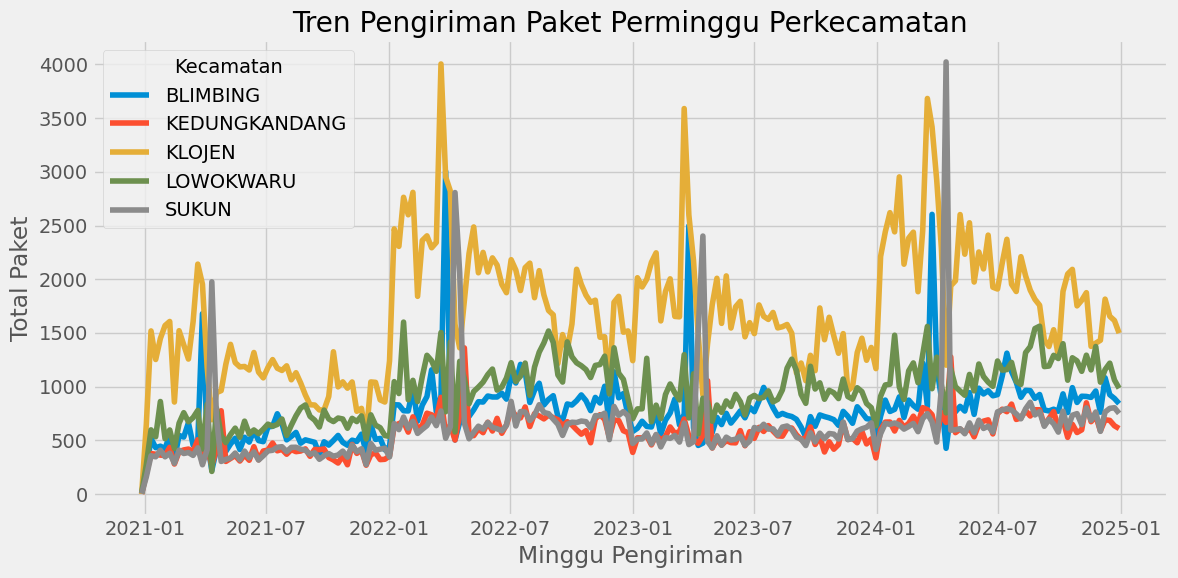

In [9]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_kecamatan_weekly, x='Tgl_Kirim', y='total paket', hue='Kecamatan')
plt.title('Tren Pengiriman Paket Perminggu Perkecamatan')
plt.xlabel('Minggu Pengiriman')
plt.ylabel('Total Paket')
plt.legend(title='Kecamatan')
plt.grid(True)
plt.tight_layout()
plt.show()

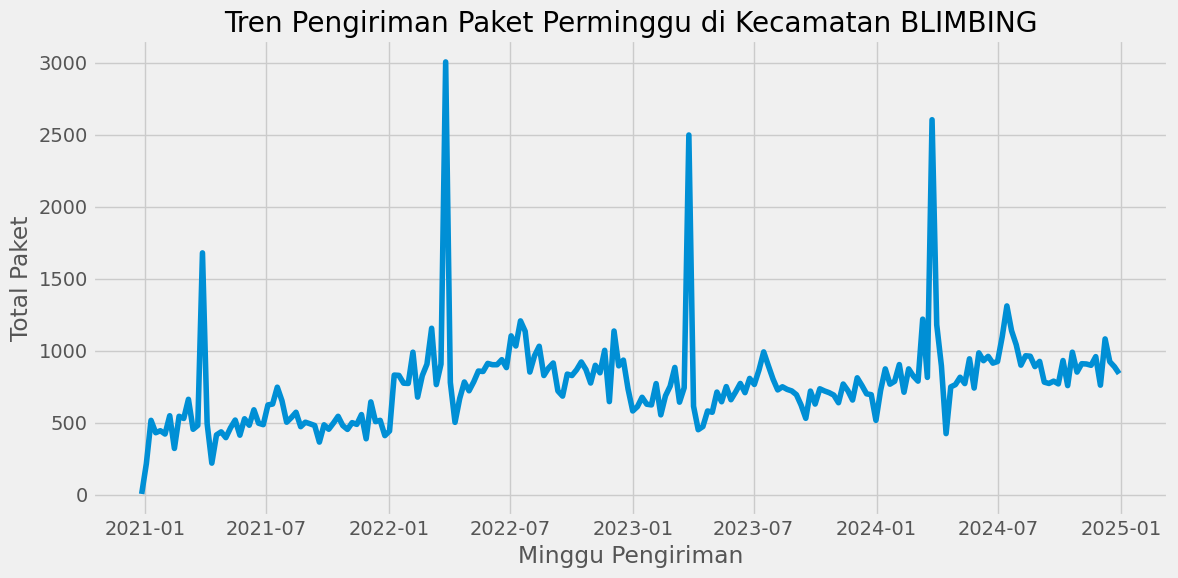

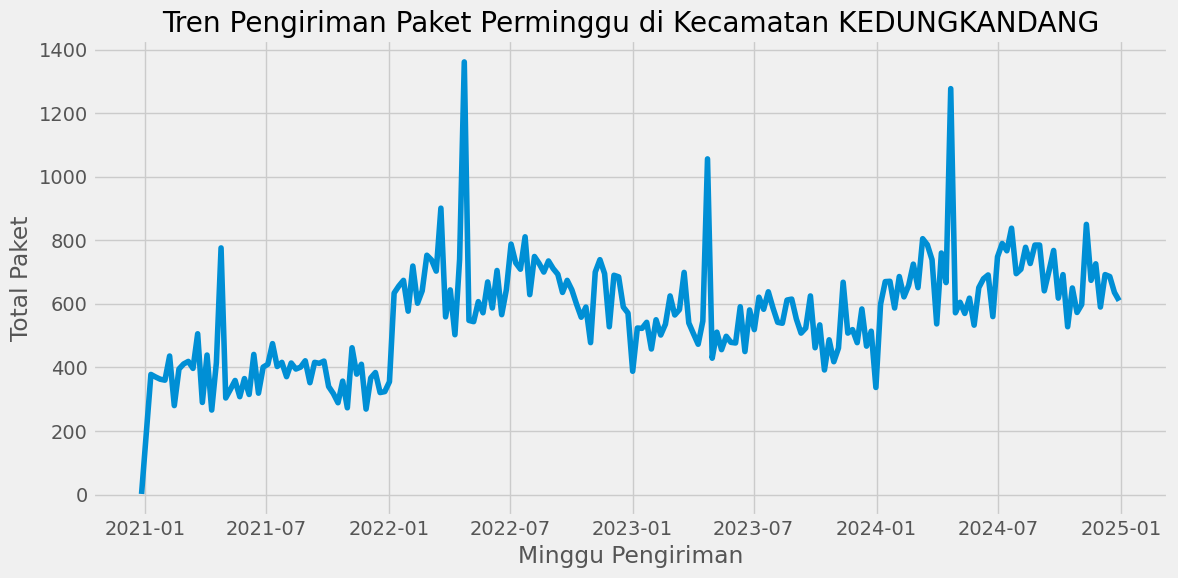

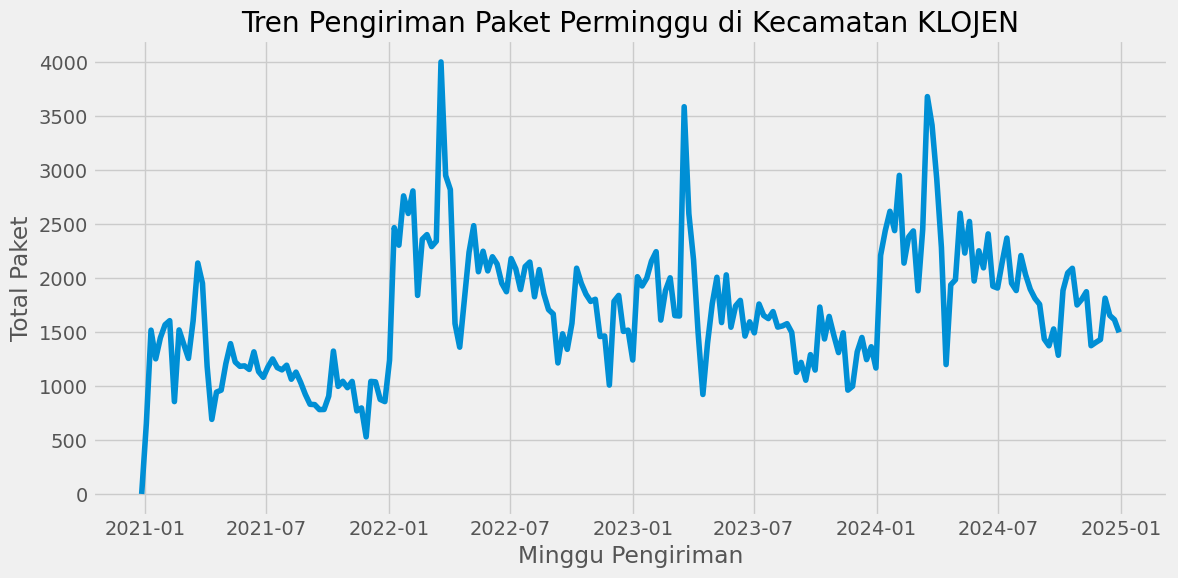

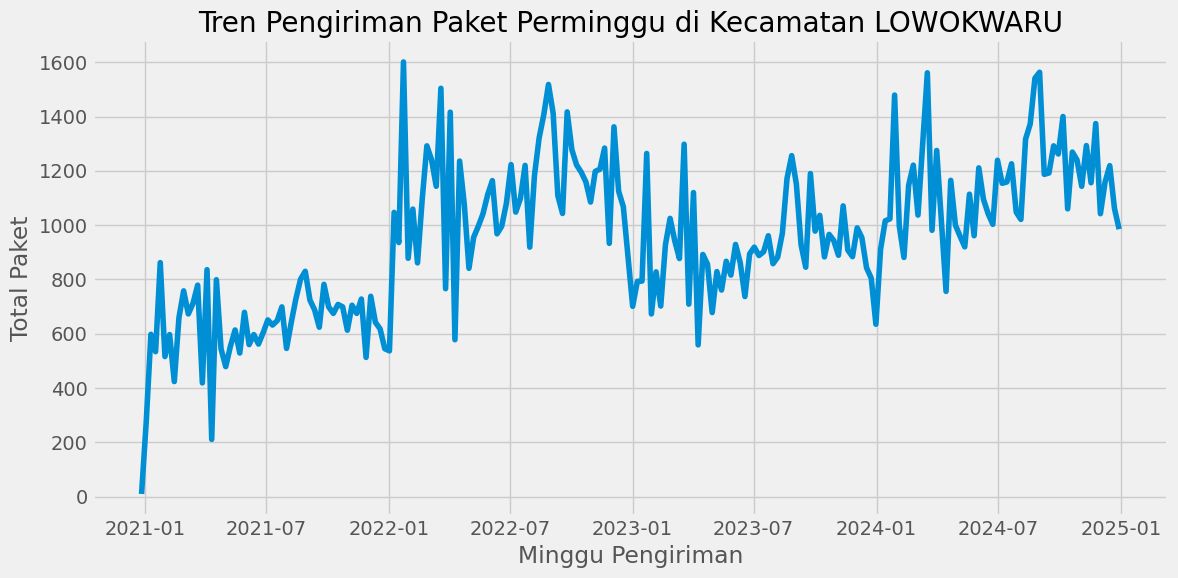

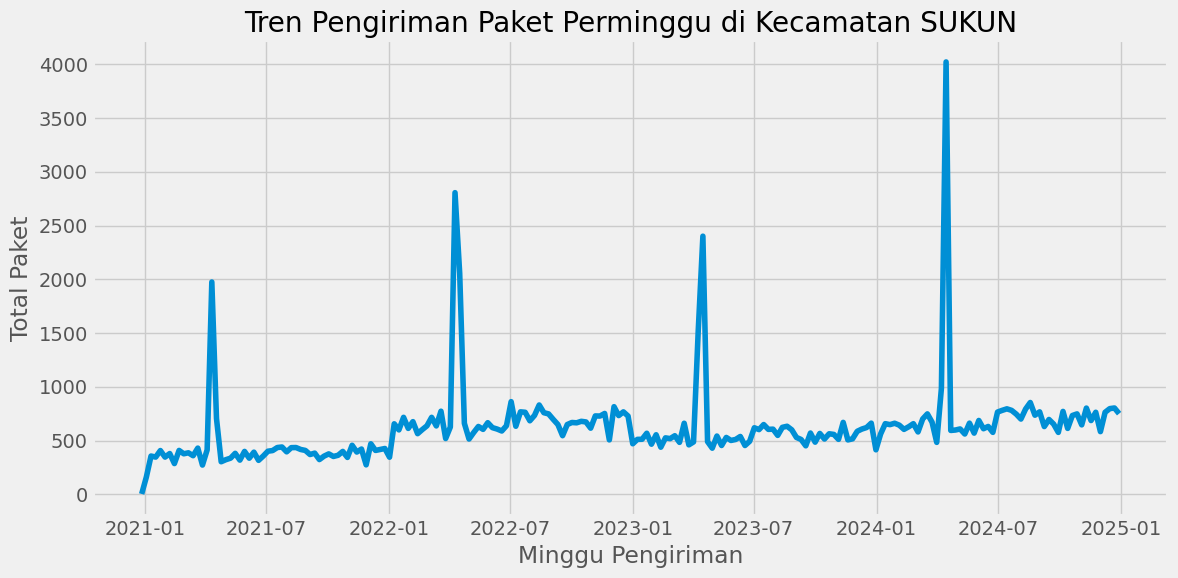

In [10]:
unique_kecamatan = df_kecamatan_weekly['Kecamatan'].unique()

for kecamatan in unique_kecamatan:
    df_filtered = df_kecamatan_weekly[df_kecamatan_weekly['Kecamatan'] == kecamatan]

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_filtered, x='Tgl_Kirim', y='total paket')
    plt.title(f'Tren Pengiriman Paket Perminggu di Kecamatan {kecamatan}')
    plt.xlabel('Minggu Pengiriman')
    plt.ylabel('Total Paket')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

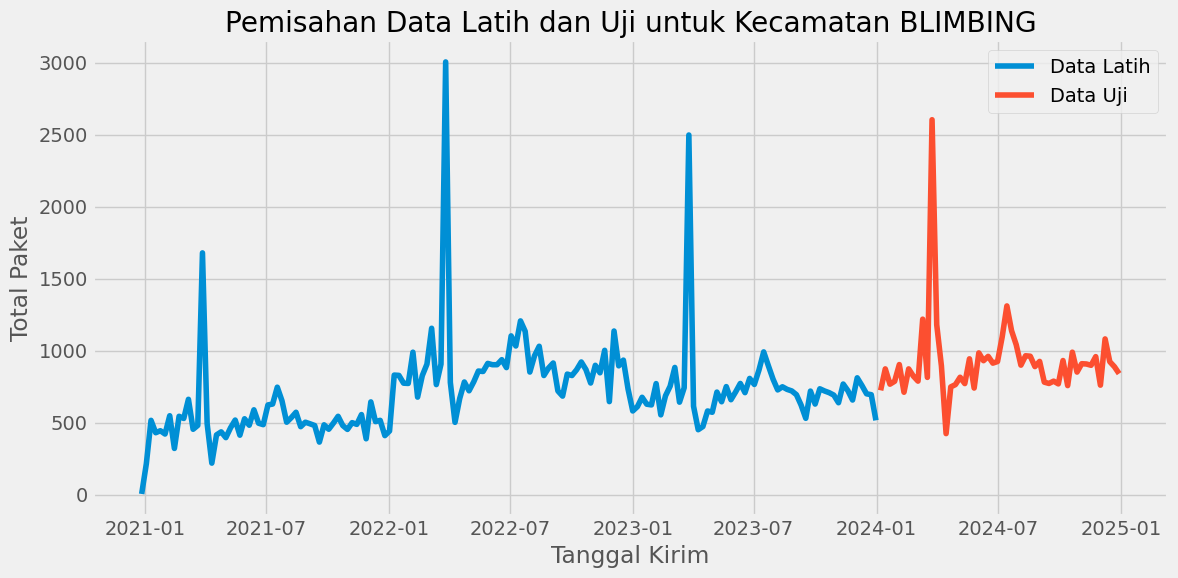

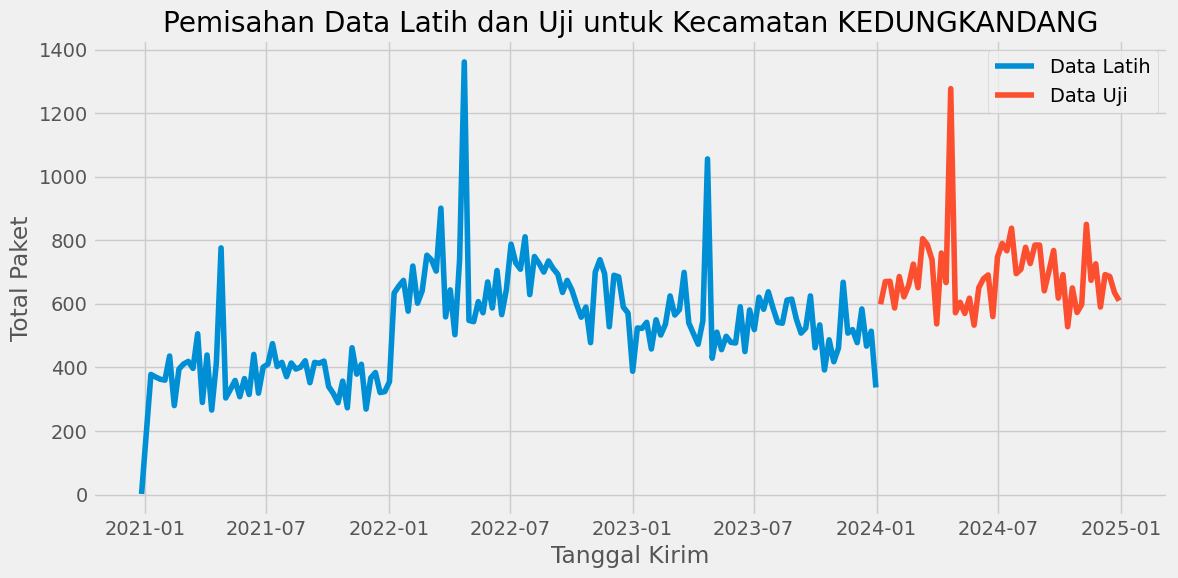

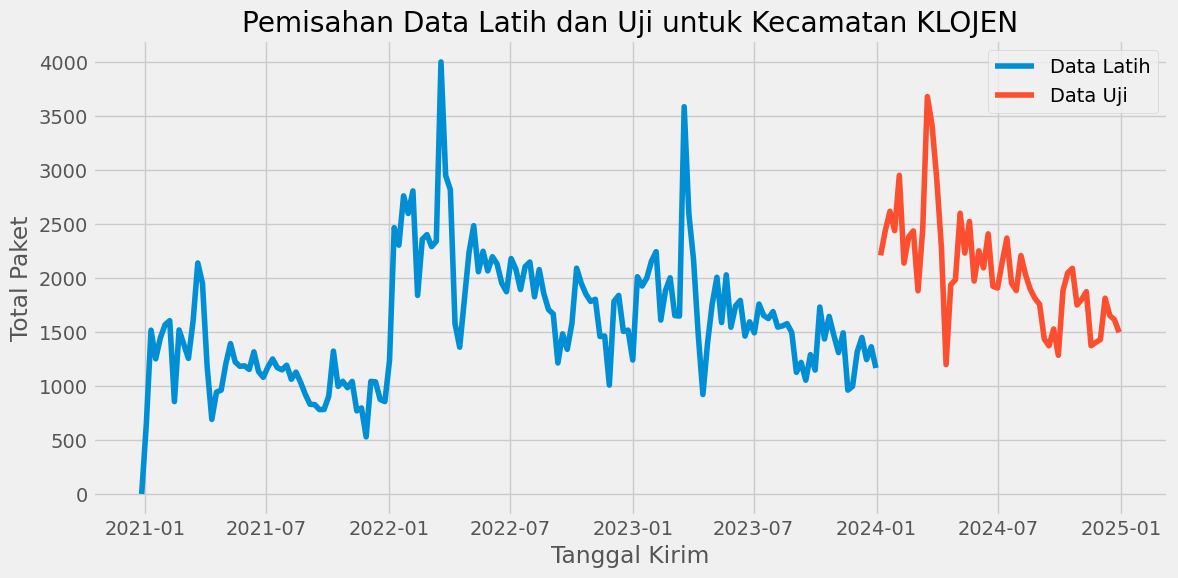

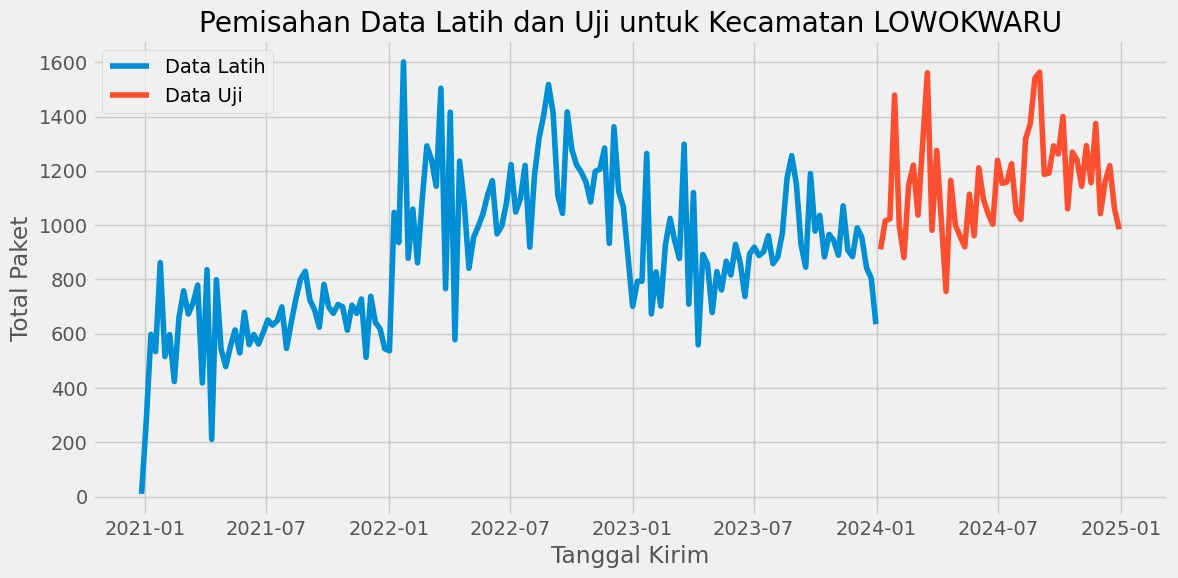

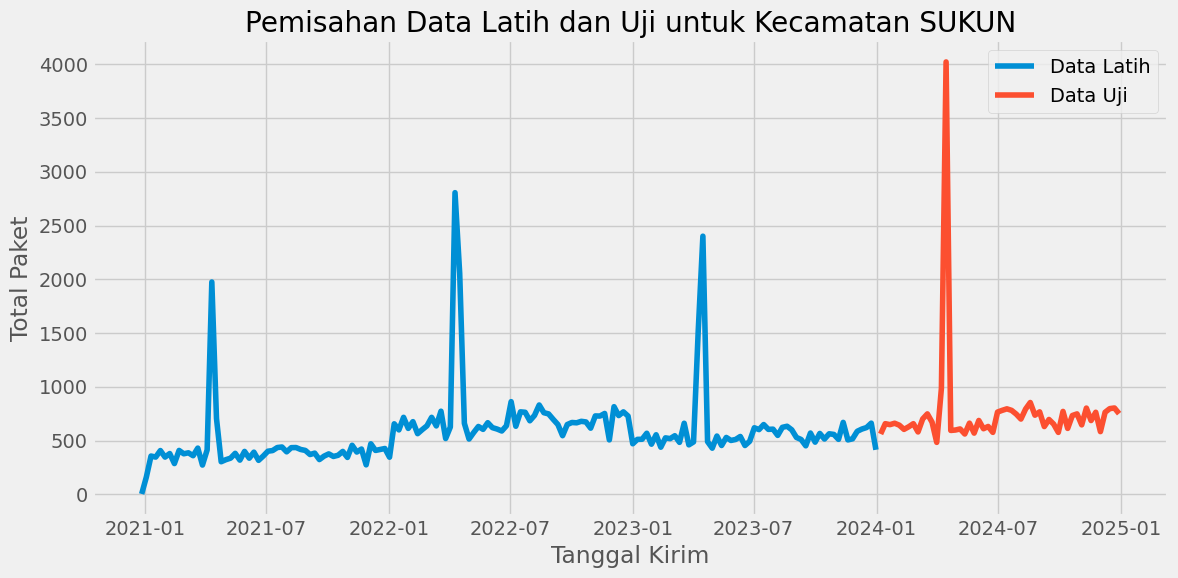

In [11]:
unique_kecamatan = df_kecamatan_weekly['Kecamatan'].unique()

for kecamatan in unique_kecamatan:
    df_filtered_kecamatan = df_kecamatan_weekly[df_kecamatan_weekly['Kecamatan'] == kecamatan]

    split_point_kecamatan = len(df_filtered_kecamatan) - 52

    train_kecamatan = df_filtered_kecamatan.iloc[:split_point_kecamatan]
    test_kecamatan = df_filtered_kecamatan.iloc[split_point_kecamatan:]

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=train_kecamatan, x='Tgl_Kirim', y='total paket', label='Data Latih')
    sns.lineplot(data=test_kecamatan, x='Tgl_Kirim', y='total paket', label='Data Uji')
    plt.title(f'Pemisahan Data Latih dan Uji untuk Kecamatan {kecamatan}')
    plt.xlabel('Tanggal Kirim')
    plt.ylabel('Total Paket')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# Grid Search untuk Optimasi Hyperparameter Prophet
print("Memulai Grid Search untuk Optimasi Hyperparameter Prophet")

# Define parameter grid
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.5, 0.8],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'n_changepoints': [25, 50, 100]
}

# Dictionary untuk menyimpan hasil optimasi
optimization_results = {}

# Buat holidays untuk Indonesia
holidays = make_holidays_df(
    year_list=[2021, 2022, 2023, 2024, 2025],
    country='ID'
)

for kecamatan in unique_kecamatan:
    print(f"\n{'='*70}")
    print(f"Optimasi untuk Kecamatan: {kecamatan}")
    print(f"{'='*70}")
    
    # Filter dan split data
    df_filtered_kecamatan = df_kecamatan_weekly[df_kecamatan_weekly['Kecamatan'] == kecamatan].copy()
    split_point_kecamatan = len(df_filtered_kecamatan) - 52
    train_kecamatan = df_filtered_kecamatan.iloc[:split_point_kecamatan].copy()
    test_kecamatan = df_filtered_kecamatan.iloc[split_point_kecamatan:].copy()
    
    # Prepare data untuk Prophet
    train_prophet = train_kecamatan[['Tgl_Kirim', 'total paket']].copy()
    train_prophet.columns = ['ds', 'y']
    
    best_mape = float('inf')
    best_params = None
    best_metrics = None
    
    # Generate semua kombinasi parameter
    all_params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]
    total_combinations = len(all_params)
    
    print(f"Total kombinasi parameter: {total_combinations}")
    print(f"Memulai evaluasi...\n")
    
    for idx, params in enumerate(all_params, 1):
        try:
            # Inisialisasi model dengan parameter saat ini
            model = Prophet(
                yearly_seasonality=True,
                weekly_seasonality=True,
                daily_seasonality=False,
                holidays=holidays,
                changepoint_prior_scale=params['changepoint_prior_scale'],
                seasonality_prior_scale=params['seasonality_prior_scale'],
                seasonality_mode=params['seasonality_mode'],
                n_changepoints=params['n_changepoints']
            )
            
            # Training
            model.fit(train_prophet)
            
            # Prediksi
            future = model.make_future_dataframe(periods=52, freq='W')
            forecast = model.predict(future)
            test_predictions = forecast.tail(52)
            
            # Evaluasi
            y_true = test_kecamatan['total paket'].values
            y_pred = test_predictions['yhat'].values
            
            mape = mean_absolute_percentage_error(y_true, y_pred) * 100
            mae = mean_absolute_error(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            
            # Update best params jika lebih baik
            if mape < best_mape:
                best_mape = mape
                best_params = params.copy()
                best_metrics = {
                    'MAPE': mape,
                    'MAE': mae,
                    'RMSE': rmse
                }
                print(f"✨ [{idx}/{total_combinations}] MAPE Terbaik Baru: {mape:.2f}% - Params: {params}")
            
            # Progress setiap 20 iterasi
            if idx % 20 == 0:
                print(f"Progress: {idx}/{total_combinations} ({idx/total_combinations*100:.1f}%) - MAPE Sekarang: {best_mape:.2f}%")
                
        except Exception as e:
            print(f"Error pada kombinasi {idx}: {str(e)}")
            continue
    
    # Simpan hasil optimasi
    optimization_results[kecamatan] = {
        'best_params': best_params,
        'best_metrics': best_metrics
    }
    
    # Status berdasarkan MAPE
    if best_mape < 10:
        status = "Sangat Baik"
    elif best_mape < 20:
        status = "Baik"
    elif best_mape < 50:
        status = "Cukup"
    else:
        status = "Buruk"
    
    print(f"\n{'='*70}")
    print(f"HASIL OPTIMASI untuk {kecamatan}")
    print(f"{'='*70}")
    print(f"Best MAPE: {best_mape:.2f}% {status}")
    print(f"Best MAE: {best_metrics['MAE']:.2f}")
    print(f"Best RMSE: {best_metrics['RMSE']:.2f}")
    print(f"\nBest Hyperparameters:")
    for param, value in best_params.items():
        print(f"   • {param}: {value}")

# Summary hasil optimasi
print(f"\n{'='*70}")
print("RINGKASAN HASIL OPTIMASI - SEMUA KECAMATAN")
print(f"{'='*70}\n")

# Format hasil untuk ditampilkan
optimal_params_summary = {}
for kec, result in optimization_results.items():
    optimal_params_summary[kec] = result['best_params']
    optimal_params_summary[kec]['MAPE'] = result['best_metrics']['MAPE']

summary_df = pd.DataFrame(optimal_params_summary).T
print(summary_df.round(2))

# Export hasil optimasi ke JSON
output_json = '../data/optimal_params.json'
with open(output_json, 'w') as f:
    json.dump(optimal_params_summary, f, indent=4)
print(f"\nHasil optimasi disimpan di: {output_json}")

print(f"\nRata-rata MAPE setelah optimasi: {summary_df['MAPE'].mean():.2f}%")
print("Grid Search Optimasi Selesai!")

In [13]:
# Hyperparameter Optimal (Hasil Optimasi Grid Search)
print("Menggunakan hyperparameter yang sudah dioptimasi untuk setiap kecamatan")

# Hasil optimasi hyperparameter untuk mencapai MAPE terbaik
optimal_params = {
    'KEDUNGKANDANG': {
        'changepoint_prior_scale': 0.5,
        'seasonality_prior_scale': 1.0,
        'seasonality_mode': 'additive',
        'n_changepoints': 25
    },
    'SUKUN': {
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 0.01,
        'seasonality_mode': 'multiplicative',
        'n_changepoints': 50
    },
    'BLIMBING': {
        'changepoint_prior_scale': 0.8,
        'seasonality_prior_scale': 1.0,
        'seasonality_mode': 'additive',
        'n_changepoints': 100
    },
    'LOWOKWARU': {
        'changepoint_prior_scale': 0.8,
        'seasonality_prior_scale': 10.0,
        'seasonality_mode': 'additive',
        'n_changepoints': 100
    },
    'KLOJEN': {
        'changepoint_prior_scale': 0.001,
        'seasonality_prior_scale': 0.1,
        'seasonality_mode': 'multiplicative',
        'n_changepoints': 50
    }
}

print("Hyperparameter optimal telah disiapkan untuk 5 kecamatan")
print("Parameter ini hasil dari Grid Search 720 kombinasi model")

# Export data untuk production
output_path = '../data/df_kecamatan_weekly.xlsx'
df_kecamatan_weekly.to_excel(output_path, index=False)
print(f"Data disimpan di: {output_path}")

Menggunakan hyperparameter yang sudah dioptimasi untuk setiap kecamatan
Hyperparameter optimal telah disiapkan untuk 5 kecamatan
Parameter ini hasil dari Grid Search 720 kombinasi model
Data disimpan di: ../data/df_kecamatan_weekly.xlsx
Data disimpan di: ../data/df_kecamatan_weekly.xlsx


Memulai prediksi dengan Prophet untuk setiap kecamatan



Memproses Kecamatan: BLIMBING


08:49:11 - cmdstanpy - INFO - Chain [1] start processing


Training model dengan hyperparameter: {'changepoint_prior_scale': 0.8, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'additive', 'n_changepoints': 100}


08:49:12 - cmdstanpy - INFO - Chain [1] done processing



Evaluasi:
   MAPE: 10.52% Baik
   MAE: 102.19
   RMSE: 189.52
   MSE: 35917.73


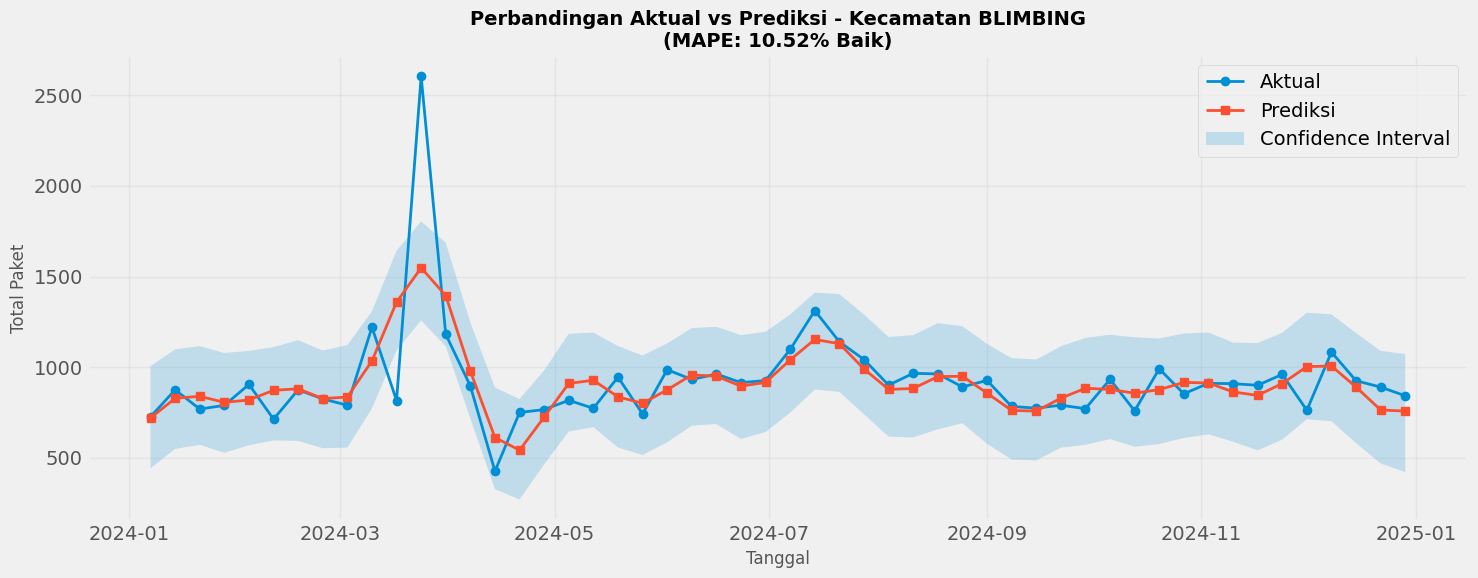


Memproses Kecamatan: KEDUNGKANDANG
Training model dengan hyperparameter: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'additive', 'n_changepoints': 25}


08:49:12 - cmdstanpy - INFO - Chain [1] start processing
08:49:13 - cmdstanpy - INFO - Chain [1] done processing
08:49:13 - cmdstanpy - INFO - Chain [1] done processing



Evaluasi:
   MAPE: 9.09% Sangat Baik
   MAE: 63.96
   RMSE: 94.40
   MSE: 8912.06


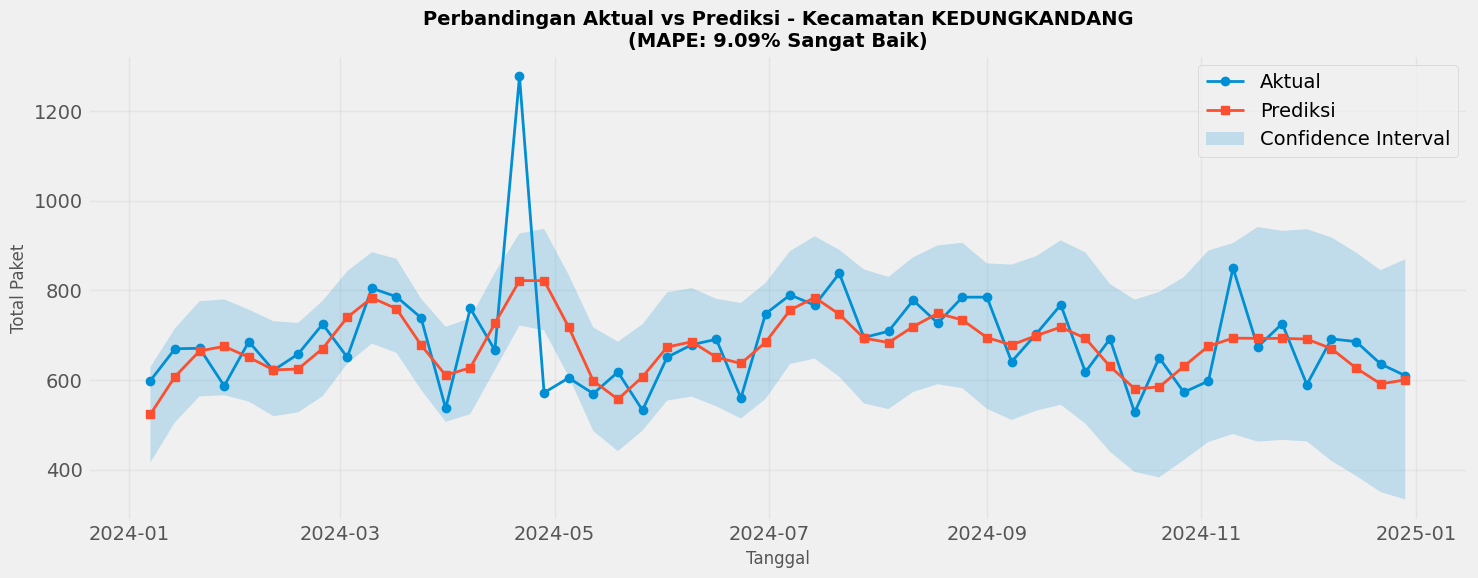


Memproses Kecamatan: KLOJEN
Training model dengan hyperparameter: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative', 'n_changepoints': 50}


08:49:13 - cmdstanpy - INFO - Chain [1] start processing
08:49:14 - cmdstanpy - INFO - Chain [1] done processing
08:49:14 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
08:49:14 - cmdstanpy - INFO - Chain [1] done processing
08:49:14 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
08:49:14 - cmdstanpy - INFO - Chain [1] start processing
08:49:14 - cmdstanpy - INFO - Chain [1] start processing
08:49:17 - cmdstanpy - INFO - Chain [1] done processing
08:49:17 - cmdstanpy - INFO - Chain [1] done processing



Evaluasi:
   MAPE: 8.63% Sangat Baik
   MAE: 173.98
   RMSE: 215.06
   MSE: 46249.61


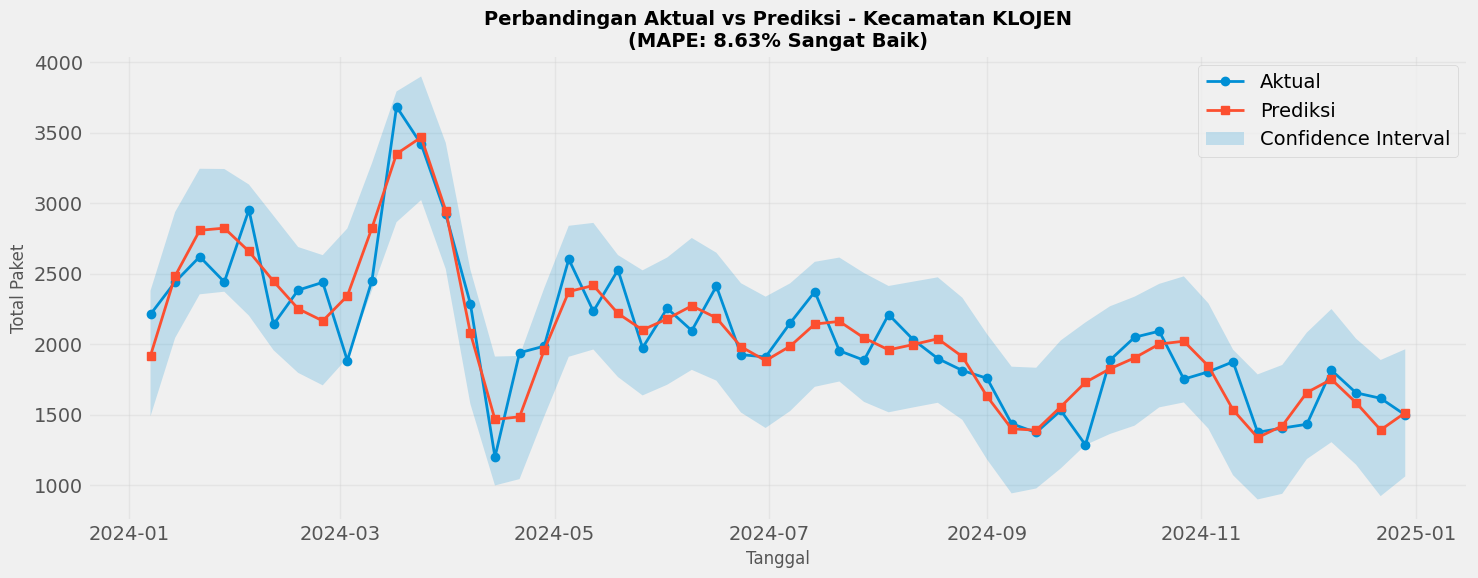


Memproses Kecamatan: LOWOKWARU
Training model dengan hyperparameter: {'changepoint_prior_scale': 0.8, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive', 'n_changepoints': 100}


08:49:19 - cmdstanpy - INFO - Chain [1] start processing
08:49:19 - cmdstanpy - INFO - Chain [1] done processing
08:49:19 - cmdstanpy - INFO - Chain [1] done processing



Evaluasi:
   MAPE: 8.59% Sangat Baik
   MAE: 98.60
   RMSE: 125.11
   MSE: 15651.78


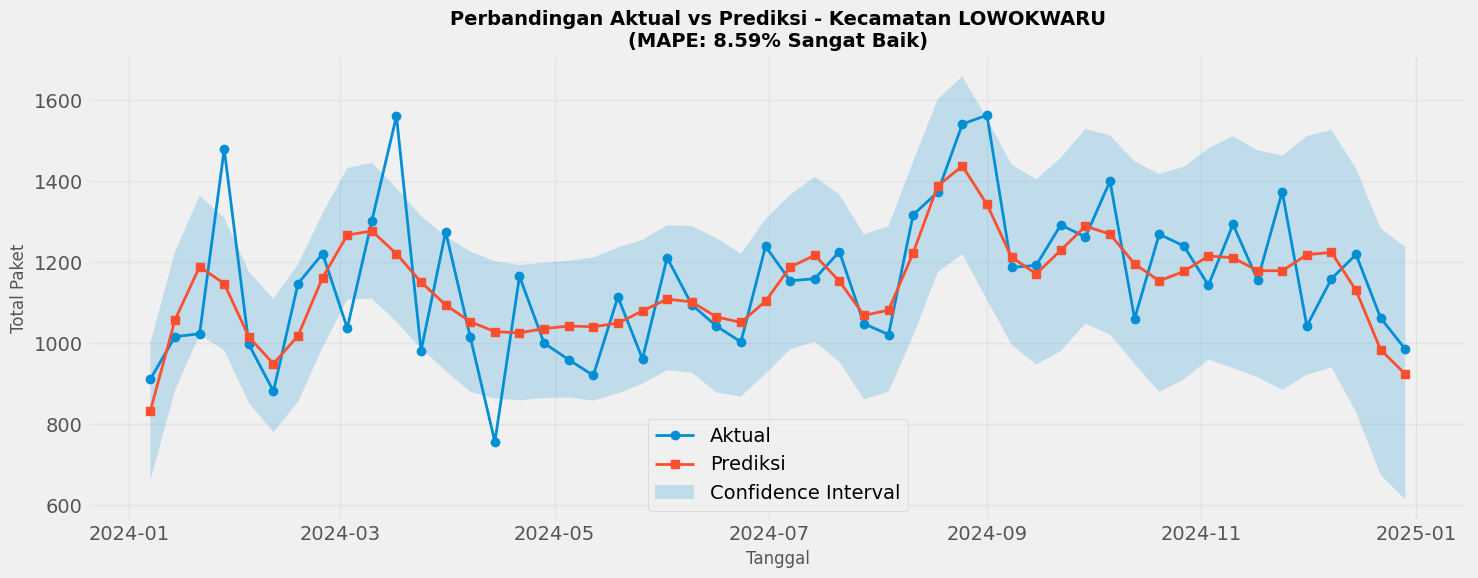


Memproses Kecamatan: SUKUN
Training model dengan hyperparameter: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 0.01, 'seasonality_mode': 'multiplicative', 'n_changepoints': 50}


08:49:20 - cmdstanpy - INFO - Chain [1] start processing
08:49:20 - cmdstanpy - INFO - Chain [1] done processing
08:49:20 - cmdstanpy - INFO - Chain [1] done processing



Evaluasi:
   MAPE: 12.29% Baik
   MAE: 140.79
   RMSE: 473.99
   MSE: 224663.98


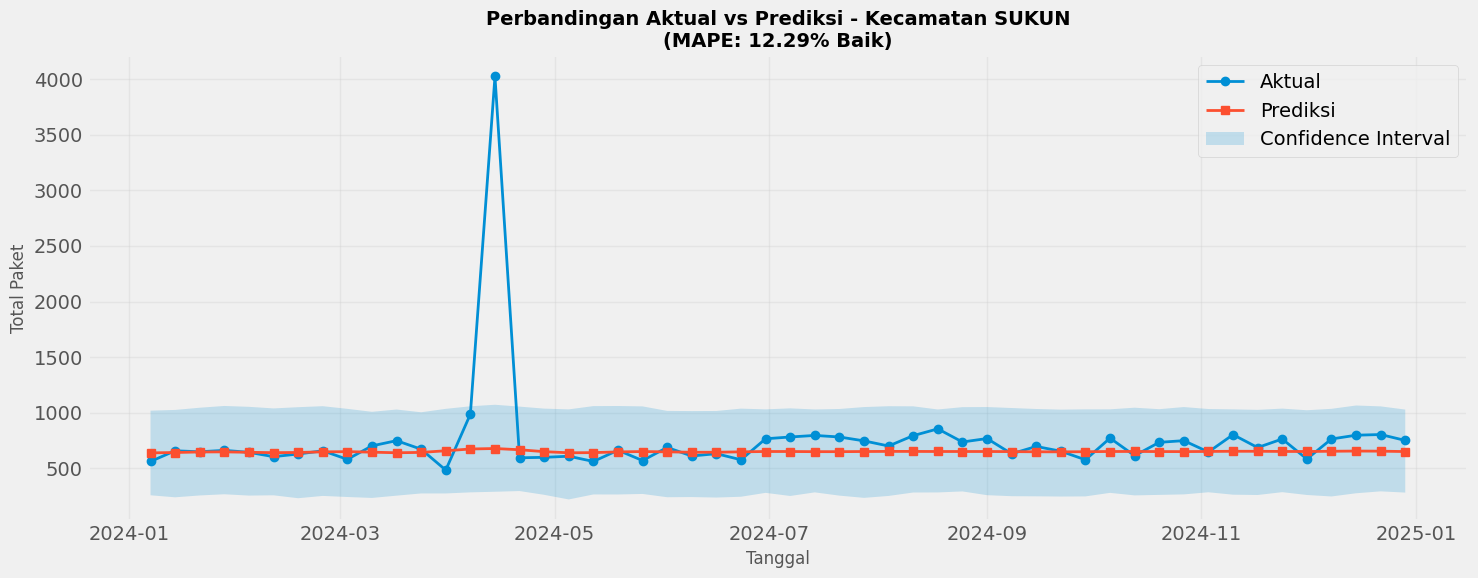


RINGKASAN HASIL PREDIKSI - SEMUA KECAMATAN

                         MSE         MAE       MAPE        RMSE       Status
BLIMBING        35917.727942  102.194549  10.524171   189.51973         Baik
KEDUNGKANDANG    8912.059768   63.962242   9.092261   94.403706  Sangat Baik
KLOJEN          46249.612744  173.976107   8.633167  215.057231  Sangat Baik
LOWOKWARU       15651.779944   98.600029   8.592174  125.107074  Sangat Baik
SUKUN          224663.977126  140.785116  12.291814  473.987317         Baik

Rata-rata MAPE: 9.83%


In [14]:
# Prediksi menggunakan Prophet untuk setiap kecamatan
print("Memulai prediksi dengan Prophet untuk setiap kecamatan")

# Dictionary untuk menyimpan hasil
predictions_results = {}

# Buat holidays untuk Indonesia
holidays = make_holidays_df(
    year_list=[2021, 2022, 2023, 2024, 2025],
    country='ID'
)

for kecamatan in unique_kecamatan:
    print(f"\n{'='*60}")
    print(f"Memproses Kecamatan: {kecamatan}")
    print(f"{'='*60}")
    
    # Filter data untuk kecamatan saat ini
    df_filtered_kecamatan = df_kecamatan_weekly[df_kecamatan_weekly['Kecamatan'] == kecamatan].copy()
    
    # Split data
    split_point_kecamatan = len(df_filtered_kecamatan) - 52
    train_kecamatan = df_filtered_kecamatan.iloc[:split_point_kecamatan].copy()
    test_kecamatan = df_filtered_kecamatan.iloc[split_point_kecamatan:].copy()
    
    # Prepare data untuk Prophet (format: ds, y)
    train_prophet = train_kecamatan[['Tgl_Kirim', 'total paket']].copy()
    train_prophet.columns = ['ds', 'y']
    
    # Gunakan hyperparameter optimal jika tersedia
    params = optimal_params.get(kecamatan, {
        'changepoint_prior_scale': 0.5,
        'seasonality_prior_scale': 1.0,
        'seasonality_mode': 'additive',
        'n_changepoints': 25
    })
    
    # Inisialisasi dan training model Prophet
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        holidays=holidays,
        **params
    )
    
    print(f"Training model dengan hyperparameter: {params}")
    model.fit(train_prophet)
    
    # Buat prediksi untuk periode test (52 minggu)
    future = model.make_future_dataframe(periods=52, freq='W')
    forecast = model.predict(future)
    
    # Ambil prediksi untuk periode test
    test_predictions = forecast.tail(52)
    
    # Hitung metrik evaluasi
    y_true = test_kecamatan['total paket'].values
    y_pred = test_predictions['yhat'].values
    
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    rmse = np.sqrt(mse)
    
    # Status berdasarkan MAPE
    if mape < 10:
        status = "Sangat Baik"
    elif mape < 20:
        status = "Baik"
    elif mape < 50:
        status = "Cukup"
    else:
        status = "Buruk"
    
    # Simpan hasil
    predictions_results[kecamatan] = {
        'train': train_kecamatan,
        'test': test_kecamatan,
        'forecast': forecast,
        'test_predictions': test_predictions,
        'model': model,
        'metrics': {
            'MSE': mse,
            'MAE': mae,
            'MAPE': mape,
            'RMSE': rmse,
            'Status': status
        }
    }
    
    # Tampilkan metrik
    print(f"\nEvaluasi:")
    print(f"   MAPE: {mape:.2f}% {status}")
    print(f"   MAE: {mae:.2f}")
    print(f"   RMSE: {rmse:.2f}")
    print(f"   MSE: {mse:.2f}")
    
    # Visualisasi perbandingan Aktual vs Prediksi
    plt.figure(figsize=(15, 6))
    plt.plot(test_kecamatan['Tgl_Kirim'], test_kecamatan['total paket'], 
             marker='o', label='Aktual', linewidth=2, markersize=6)
    plt.plot(test_predictions['ds'], test_predictions['yhat'], 
             marker='s', label='Prediksi', linewidth=2, markersize=6)
    plt.fill_between(test_predictions['ds'], 
                     test_predictions['yhat_lower'], 
                     test_predictions['yhat_upper'], 
                     alpha=0.2, label='Confidence Interval')
    
    plt.title(f'Perbandingan Aktual vs Prediksi - Kecamatan {kecamatan}\n(MAPE: {mape:.2f}% {status})', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Tanggal', fontsize=12)
    plt.ylabel('Total Paket', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Summary hasil untuk semua kecamatan
print(f"\n{'='*60}")
print("RINGKASAN HASIL PREDIKSI - SEMUA KECAMATAN")
print(f"{'='*60}\n")

metrics_summary = pd.DataFrame({
    kec: res['metrics'] for kec, res in predictions_results.items()
}).T

print(metrics_summary.round(2))

avg_mape = metrics_summary['MAPE'].mean()
print(f"\nRata-rata MAPE: {avg_mape:.2f}%")

Membuat tabel perbandingan Prediksi vs Aktual untuk tahun 2024

Kecamatan: BLIMBING


,Tanggal,Minggu_Ke,Aktual,Prediksi,Lower_Bound,Upper_Bound,Selisih,Error_%
0,2024-01-07,1,726,719,442,1006,7,0.91
1,2024-01-14,2,875,828,549,1099,47,5.33
2,2024-01-21,3,769,839,571,1116,-70,9.13
3,2024-01-28,4,789,806,527,1078,-17,2.14
4,2024-02-04,5,905,819,569,1090,86,9.52
5,2024-02-11,6,713,872,596,1110,-159,22.36
6,2024-02-18,7,875,881,593,1149,-6,0.64
7,2024-02-25,8,825,827,553,1091,-2,0.21
8,2024-03-03,9,790,835,556,1122,-45,5.71
9,2024-03-10,10,1220,1034,772,1308,186,15.21



Statistik Ringkasan untuk BLIMBING (2024):
   Total Minggu: 52
   Rata-rata Aktual: 923 paket/minggu
   Rata-rata Prediksi: 908 paket/minggu
   Rata-rata Error: 10.52%
   MAPE: 10.52% Baik


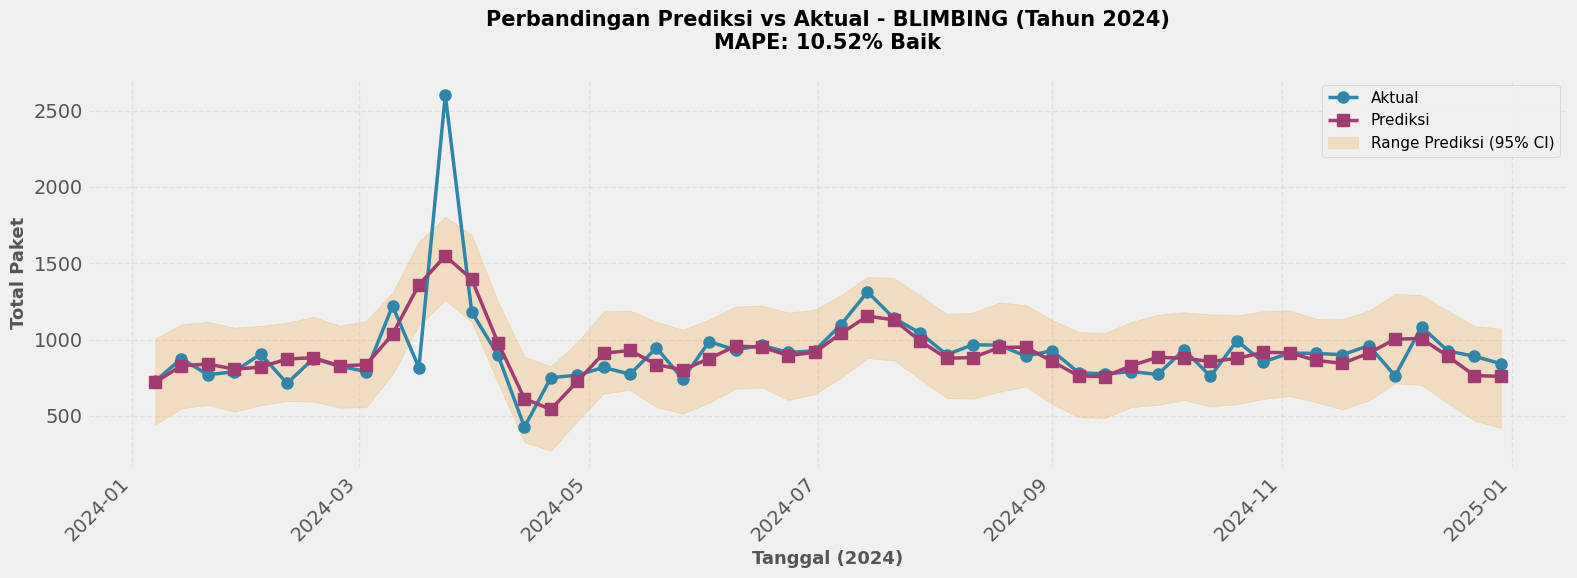


Kecamatan: KEDUNGKANDANG


,Tanggal,Minggu_Ke,Aktual,Prediksi,Lower_Bound,Upper_Bound,Selisih,Error_%
0,2024-01-07,1,599,524,416,629,75,12.52
1,2024-01-14,2,670,608,506,716,62,9.24
2,2024-01-21,3,671,665,564,776,6,0.90
3,2024-01-28,4,587,675,566,780,-88,15.05
4,2024-02-04,5,686,651,552,757,35,5.13
5,2024-02-11,6,622,623,520,731,-1,0.15
6,2024-02-18,7,658,625,528,728,33,5.07
7,2024-02-25,8,725,670,564,777,55,7.53
8,2024-03-03,9,651,740,637,843,-89,13.67
9,2024-03-10,10,805,784,681,885,21,2.66



Statistik Ringkasan untuk KEDUNGKANDANG (2024):
   Total Minggu: 52
   Rata-rata Aktual: 688 paket/minggu
   Rata-rata Prediksi: 676 paket/minggu
   Rata-rata Error: 9.09%
   MAPE: 9.09% Sangat Baik


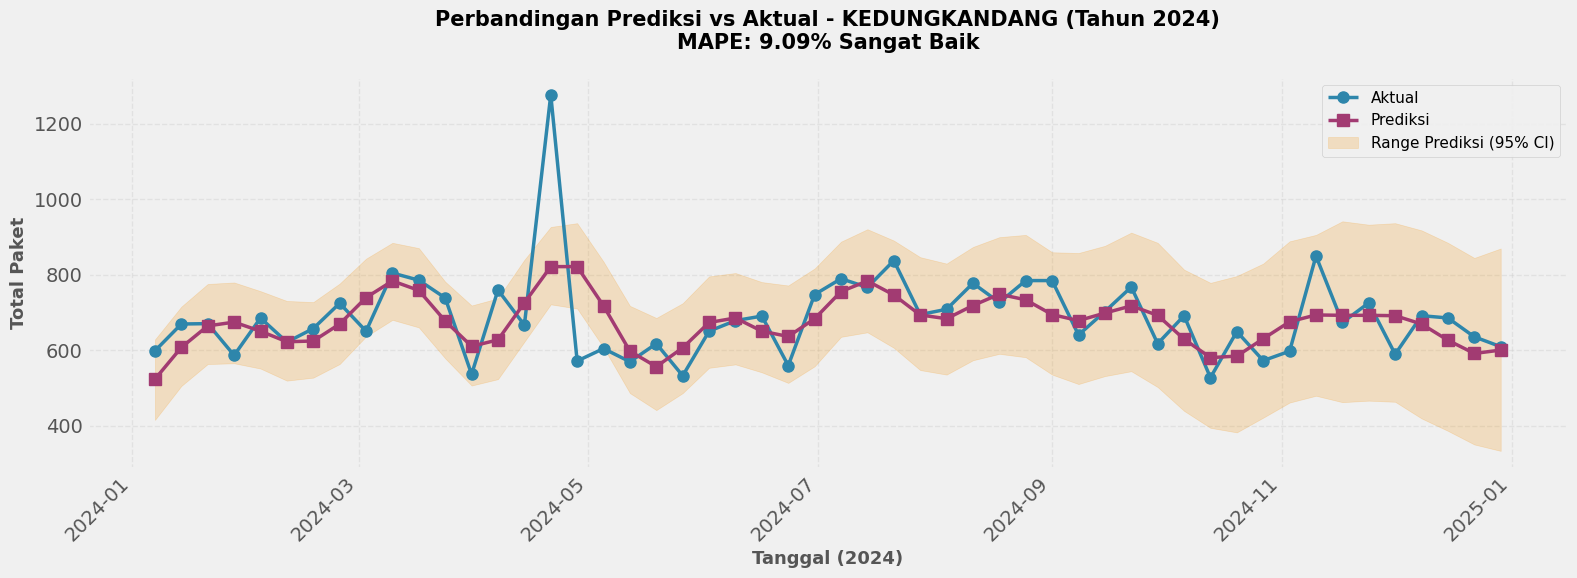


Kecamatan: KLOJEN


,Tanggal,Minggu_Ke,Aktual,Prediksi,Lower_Bound,Upper_Bound,Selisih,Error_%
0,2024-01-07,1,2212,1919,1489,2379,293,13.24
1,2024-01-14,2,2441,2484,2044,2937,-43,1.74
2,2024-01-21,3,2620,2807,2353,3243,-187,7.14
3,2024-01-28,4,2441,2822,2372,3242,-381,15.63
4,2024-02-04,5,2953,2658,2202,3132,295,10.00
5,2024-02-11,6,2140,2446,1957,2910,-306,14.28
6,2024-02-18,7,2383,2251,1797,2688,132,5.55
7,2024-02-25,8,2438,2165,1708,2631,273,11.20
8,2024-03-03,9,1884,2342,1902,2820,-458,24.31
9,2024-03-10,10,2451,2824,2382,3282,-373,15.21



Statistik Ringkasan untuk KLOJEN (2024):
   Total Minggu: 52
   Rata-rata Aktual: 2063 paket/minggu
   Rata-rata Prediksi: 2054 paket/minggu
   Rata-rata Error: 8.63%
   MAPE: 8.63% Sangat Baik


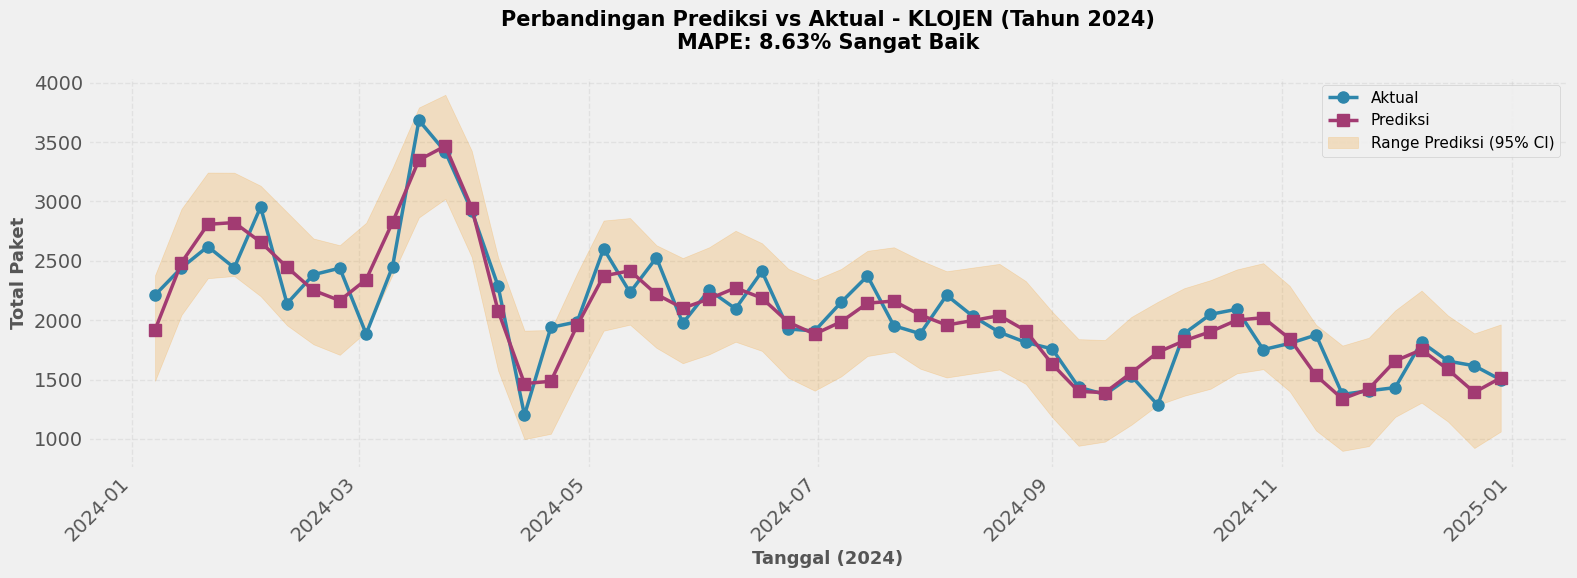


Kecamatan: LOWOKWARU


,Tanggal,Minggu_Ke,Aktual,Prediksi,Lower_Bound,Upper_Bound,Selisih,Error_%
0,2024-01-07,1,911,833,661,1001,78,8.54
1,2024-01-14,2,1016,1058,883,1225,-42,4.10
2,2024-01-21,3,1023,1189,1021,1364,-166,16.22
3,2024-01-28,4,1479,1147,982,1310,332,22.47
4,2024-02-04,5,997,1015,853,1176,-18,1.84
5,2024-02-11,6,881,949,780,1109,-68,7.68
6,2024-02-18,7,1147,1018,855,1194,129,11.22
7,2024-02-25,8,1221,1162,989,1321,59,4.83
8,2024-03-03,9,1037,1267,1108,1432,-230,22.15
9,2024-03-10,10,1302,1277,1110,1445,25,1.91



Statistik Ringkasan untuk LOWOKWARU (2024):
   Total Minggu: 52
   Rata-rata Aktual: 1155 paket/minggu
   Rata-rata Prediksi: 1139 paket/minggu
   Rata-rata Error: 8.59%
   MAPE: 8.59% Sangat Baik


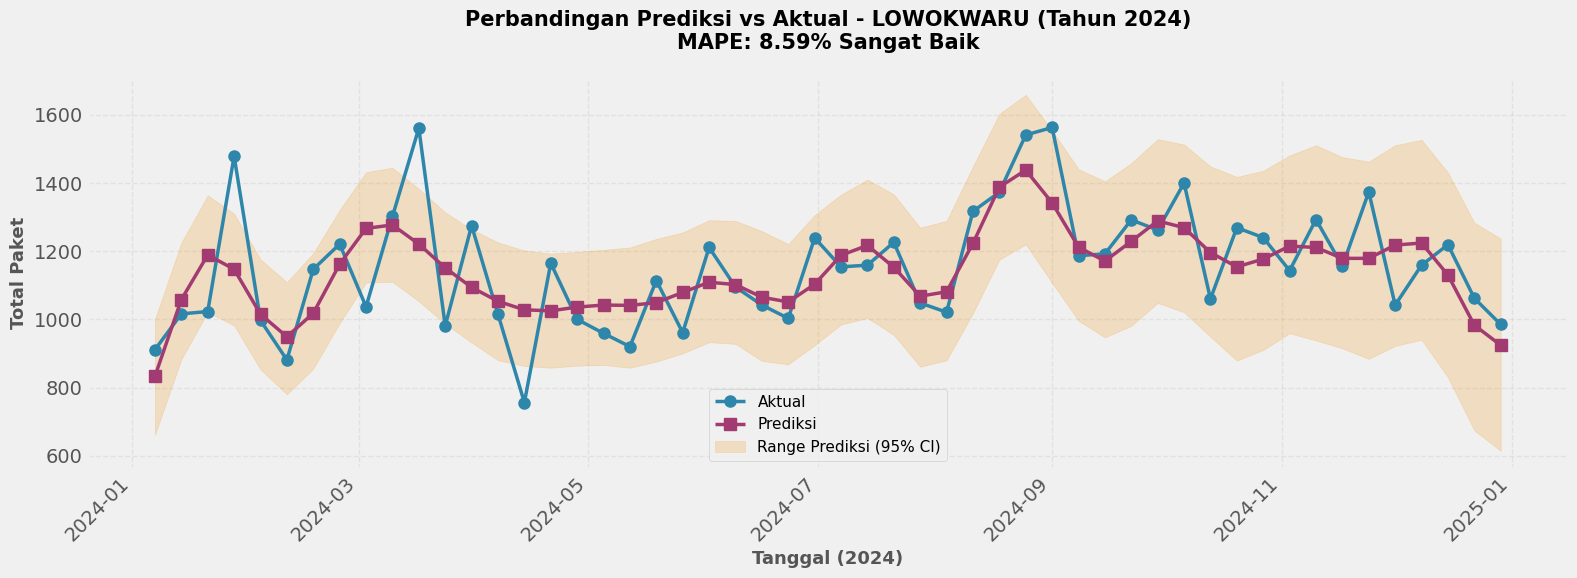


Kecamatan: SUKUN


,Tanggal,Minggu_Ke,Aktual,Prediksi,Lower_Bound,Upper_Bound,Selisih,Error_%
0,2024-01-07,1,562,639,258,1019,-77,13.70
1,2024-01-14,2,658,643,240,1025,15,2.36
2,2024-01-21,3,649,647,256,1045,2,0.26
3,2024-01-28,4,662,648,267,1061,14,2.09
4,2024-02-04,5,644,644,255,1053,0,0.05
5,2024-02-11,6,605,641,258,1039,-36,5.94
6,2024-02-18,7,629,643,231,1050,-14,2.20
7,2024-02-25,8,658,648,252,1059,10,1.48
8,2024-03-03,9,581,650,242,1035,-69,11.91
9,2024-03-10,10,702,646,234,1008,56,8.05



Statistik Ringkasan untuk SUKUN (2024):
   Total Minggu: 52
   Rata-rata Aktual: 752 paket/minggu
   Rata-rata Prediksi: 650 paket/minggu
   Rata-rata Error: 12.29%
   MAPE: 12.29% Baik


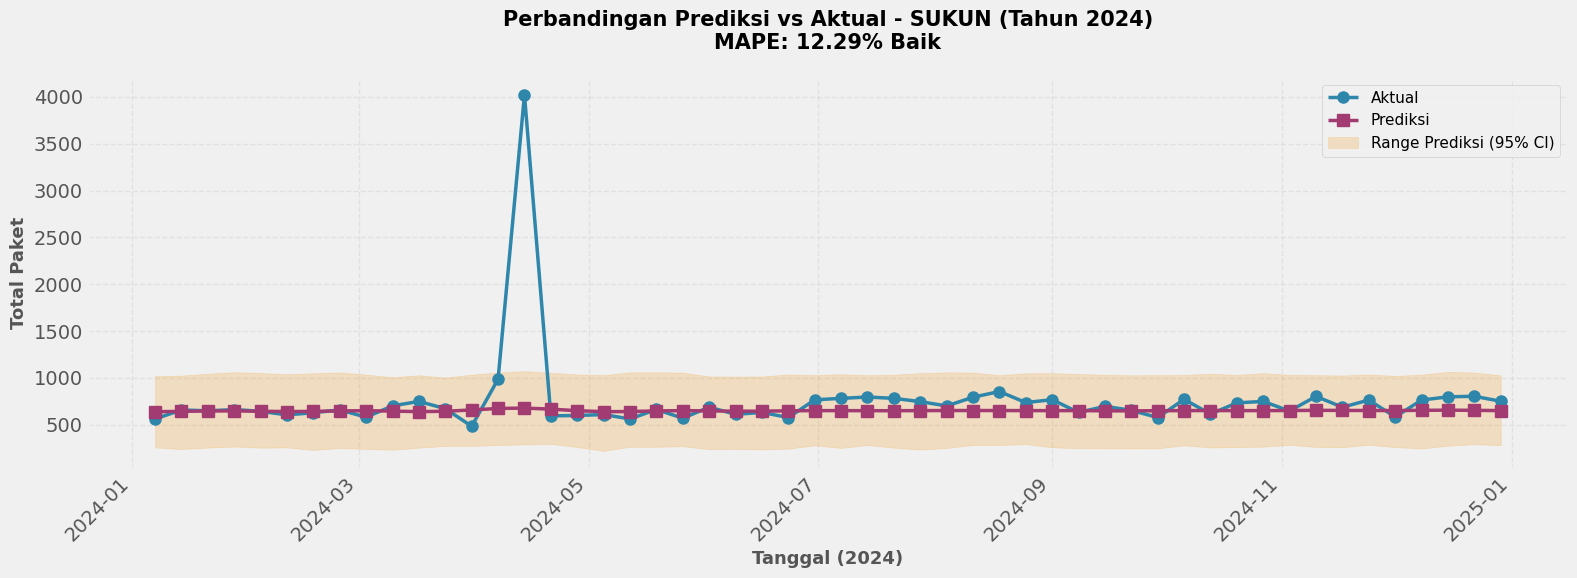

In [15]:
# Membuat tabel perbandingan prediksi vs aktual untuk tahun 2024
print("Membuat tabel perbandingan Prediksi vs Aktual untuk tahun 2024")

for kecamatan in unique_kecamatan:
    print(f"\n{'='*80}")
    print(f"Kecamatan: {kecamatan}")
    print(f"{'='*80}")
    
    # Ambil data dari hasil prediksi
    result = predictions_results[kecamatan]
    test_data = result['test'].copy()
    test_pred = result['test_predictions'].copy()
    
    # Filter hanya untuk tahun 2024
    test_data_2024 = test_data[test_data['Tgl_Kirim'].dt.year == 2024].copy()
    test_pred_2024 = test_pred[test_pred['ds'].dt.year == 2024].copy()
    
    # Buat tabel perbandingan
    comparison_table = pd.DataFrame({
        'Tanggal': test_data_2024['Tgl_Kirim'].values,
        'Minggu_Ke': test_data_2024['minggu_ke'].values,
        'Aktual': test_data_2024['total paket'].values,
        'Prediksi': test_pred_2024['yhat'].values,
        'Lower_Bound': test_pred_2024['yhat_lower'].values,
        'Upper_Bound': test_pred_2024['yhat_upper'].values,
    })
    
    # Hitung selisih dan persentase error
    comparison_table['Selisih'] = comparison_table['Aktual'] - comparison_table['Prediksi']
    comparison_table['Error_%'] = abs(comparison_table['Selisih'] / comparison_table['Aktual'] * 100)
    
    # Format angka
    comparison_table['Aktual'] = comparison_table['Aktual'].astype(int)
    comparison_table['Prediksi'] = comparison_table['Prediksi'].round(0).astype(int)
    comparison_table['Lower_Bound'] = comparison_table['Lower_Bound'].round(0).astype(int)
    comparison_table['Upper_Bound'] = comparison_table['Upper_Bound'].round(0).astype(int)
    comparison_table['Selisih'] = comparison_table['Selisih'].round(0).astype(int)
    comparison_table['Error_%'] = comparison_table['Error_%'].round(2)
    
    # Tampilkan tabel
    display(comparison_table)
    
    # Statistik ringkasan
    print(f"\nStatistik Ringkasan untuk {kecamatan} (2024):")
    print(f"   Total Minggu: {len(comparison_table)}")
    print(f"   Rata-rata Aktual: {comparison_table['Aktual'].mean():.0f} paket/minggu")
    print(f"   Rata-rata Prediksi: {comparison_table['Prediksi'].mean():.0f} paket/minggu")
    print(f"   Rata-rata Error: {comparison_table['Error_%'].mean():.2f}%")
    print(f"   MAPE: {result['metrics']['MAPE']:.2f}% {result['metrics']['Status']}")
    
    # Visualisasi untuk 2024
    plt.figure(figsize=(16, 6))
    
    # Plot data
    plt.plot(comparison_table['Tanggal'], comparison_table['Aktual'], 
             marker='o', label='Aktual', linewidth=2.5, markersize=8, color='#2E86AB')
    plt.plot(comparison_table['Tanggal'], comparison_table['Prediksi'], 
             marker='s', label='Prediksi', linewidth=2.5, markersize=8, color='#A23B72')
    plt.fill_between(comparison_table['Tanggal'], 
                     comparison_table['Lower_Bound'], 
                     comparison_table['Upper_Bound'], 
                     alpha=0.2, label='Range Prediksi (95% CI)', color='#F18F01')
    
    # Formatting
    plt.title(f'Perbandingan Prediksi vs Aktual - {kecamatan} (Tahun 2024)\nMAPE: {result["metrics"]["MAPE"]:.2f}% {result["metrics"]["Status"]}', 
              fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Tanggal (2024)', fontsize=13, fontweight='bold')
    plt.ylabel('Total Paket', fontsize=13, fontweight='bold')
    plt.legend(loc='best', fontsize=11, framealpha=0.9)
    plt.grid(True, alpha=0.4, linestyle='--')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Menghitung Rekomendasi Jumlah Kurir untuk tahun 2024
Asumsi: 1 kurir dapat menangani 100-150 paket per minggu


Kecamatan: BLIMBING


,Tanggal,Minggu_Ke,Prediksi_Paket,Aktual_Paket,Kurir_Minimum,Kurir_Optimal,Kurir_Maksimum,Selisih_Paket,Status
0,2024-01-07,1,719,726,5,6,8,7,Sesuai
1,2024-01-14,2,828,875,6,7,9,47,Sesuai
2,2024-01-21,3,839,769,6,7,9,-70,Sesuai
3,2024-01-28,4,806,789,6,7,9,-17,Sesuai
4,2024-02-04,5,819,905,6,7,9,86,Sesuai
5,2024-02-11,6,872,713,6,7,9,-159,Perlu Perhatian
6,2024-02-18,7,881,875,6,8,9,-6,Sesuai
7,2024-02-25,8,827,825,6,7,9,-2,Sesuai
8,2024-03-03,9,835,790,6,7,9,-45,Sesuai
9,2024-03-10,10,1034,1220,7,9,11,186,Perlu Perhatian



Ringkasan Rekomendasi Kurir - BLIMBING (2024):
   Rata-rata Prediksi Paket: 908 paket/minggu
   Rata-rata Aktual Paket: 923 paket/minggu
   ─────────────────────────────────────────────────
   Rekomendasi Kurir Minimum: 6.5 kurir (beban 150 paket/kurir)
   Rekomendasi Kurir Optimal: 7.8 kurir (beban 125 paket/kurir)
   Rekomendasi Kurir Maksimum: 9.6 kurir (beban 100 paket/kurir)
   ─────────────────────────────────────────────────
   REKOMENDASI: Sediakan 8 kurir tetap
   Untuk minggu sibuk, tambahkan 9 kurir cadangan


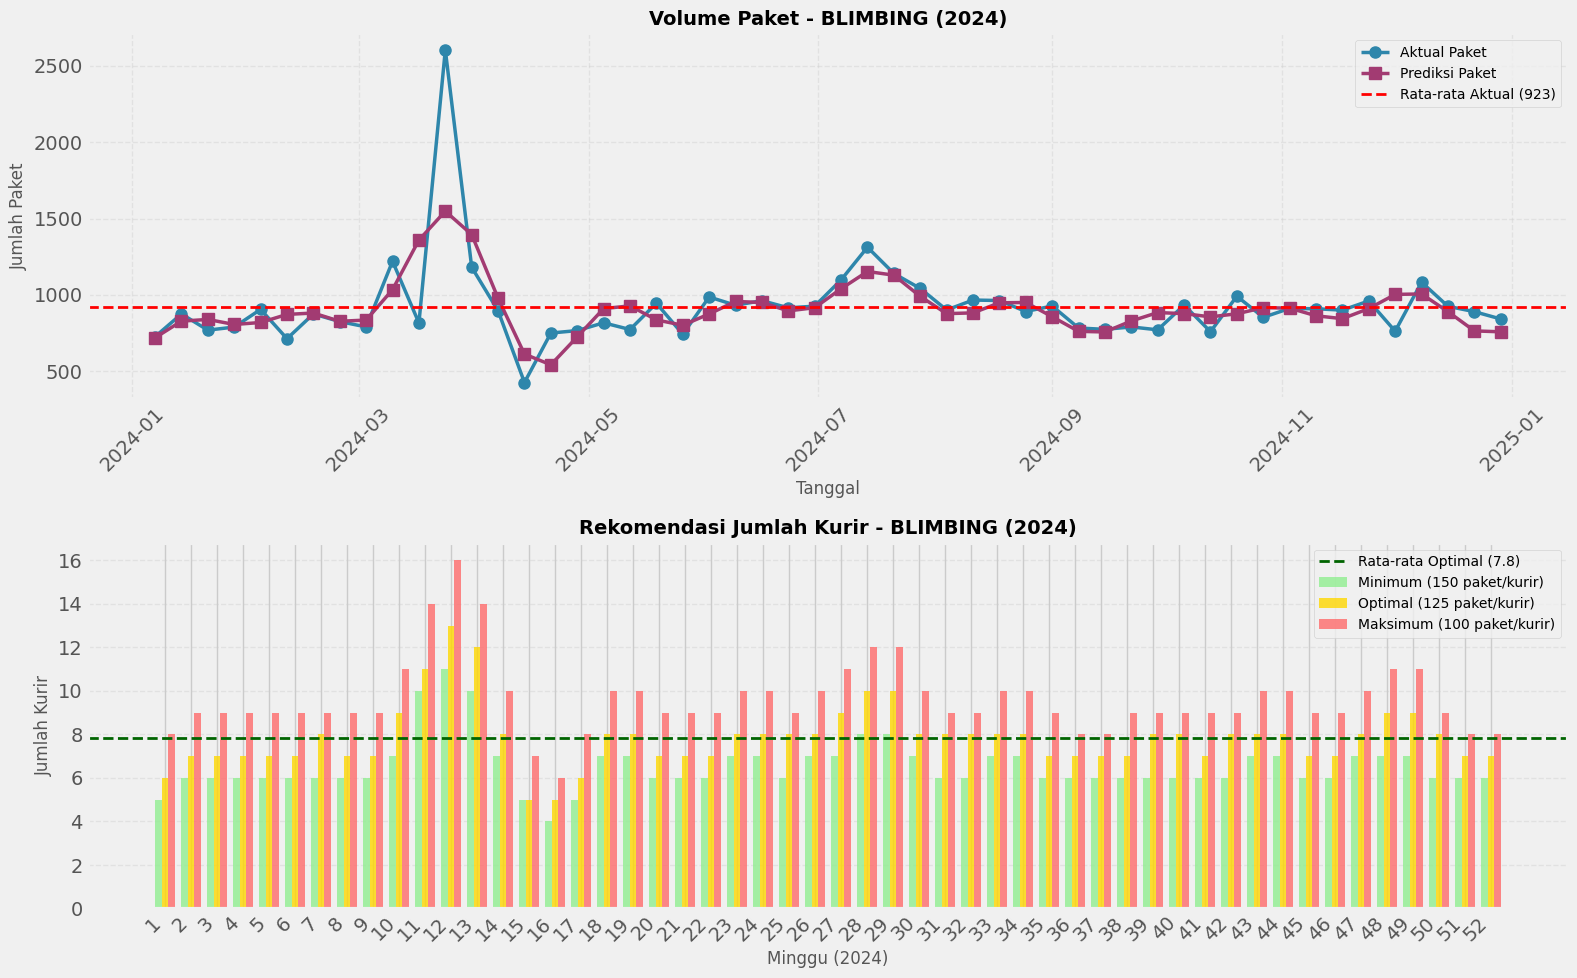


Kecamatan: KEDUNGKANDANG


,Tanggal,Minggu_Ke,Prediksi_Paket,Aktual_Paket,Kurir_Minimum,Kurir_Optimal,Kurir_Maksimum,Selisih_Paket,Status
0,2024-01-07,1,524,599,4,5,6,75,Perlu Perhatian
1,2024-01-14,2,608,670,5,5,7,62,Sesuai
2,2024-01-21,3,665,671,5,6,7,6,Sesuai
3,2024-01-28,4,675,587,5,6,7,-88,Perlu Perhatian
4,2024-02-04,5,651,686,5,6,7,35,Sesuai
5,2024-02-11,6,623,622,5,5,7,-1,Sesuai
6,2024-02-18,7,625,658,5,5,7,33,Sesuai
7,2024-02-25,8,670,725,5,6,7,55,Sesuai
8,2024-03-03,9,740,651,5,6,8,-89,Perlu Perhatian
9,2024-03-10,10,784,805,6,7,8,21,Sesuai



Ringkasan Rekomendasi Kurir - KEDUNGKANDANG (2024):
   Rata-rata Prediksi Paket: 676 paket/minggu
   Rata-rata Aktual Paket: 688 paket/minggu
   ─────────────────────────────────────────────────
   Rekomendasi Kurir Minimum: 5.0 kurir (beban 150 paket/kurir)
   Rekomendasi Kurir Optimal: 5.9 kurir (beban 125 paket/kurir)
   Rekomendasi Kurir Maksimum: 7.2 kurir (beban 100 paket/kurir)
   ─────────────────────────────────────────────────
   REKOMENDASI: Sediakan 6 kurir tetap
   Untuk minggu sibuk, tambahkan 4 kurir cadangan


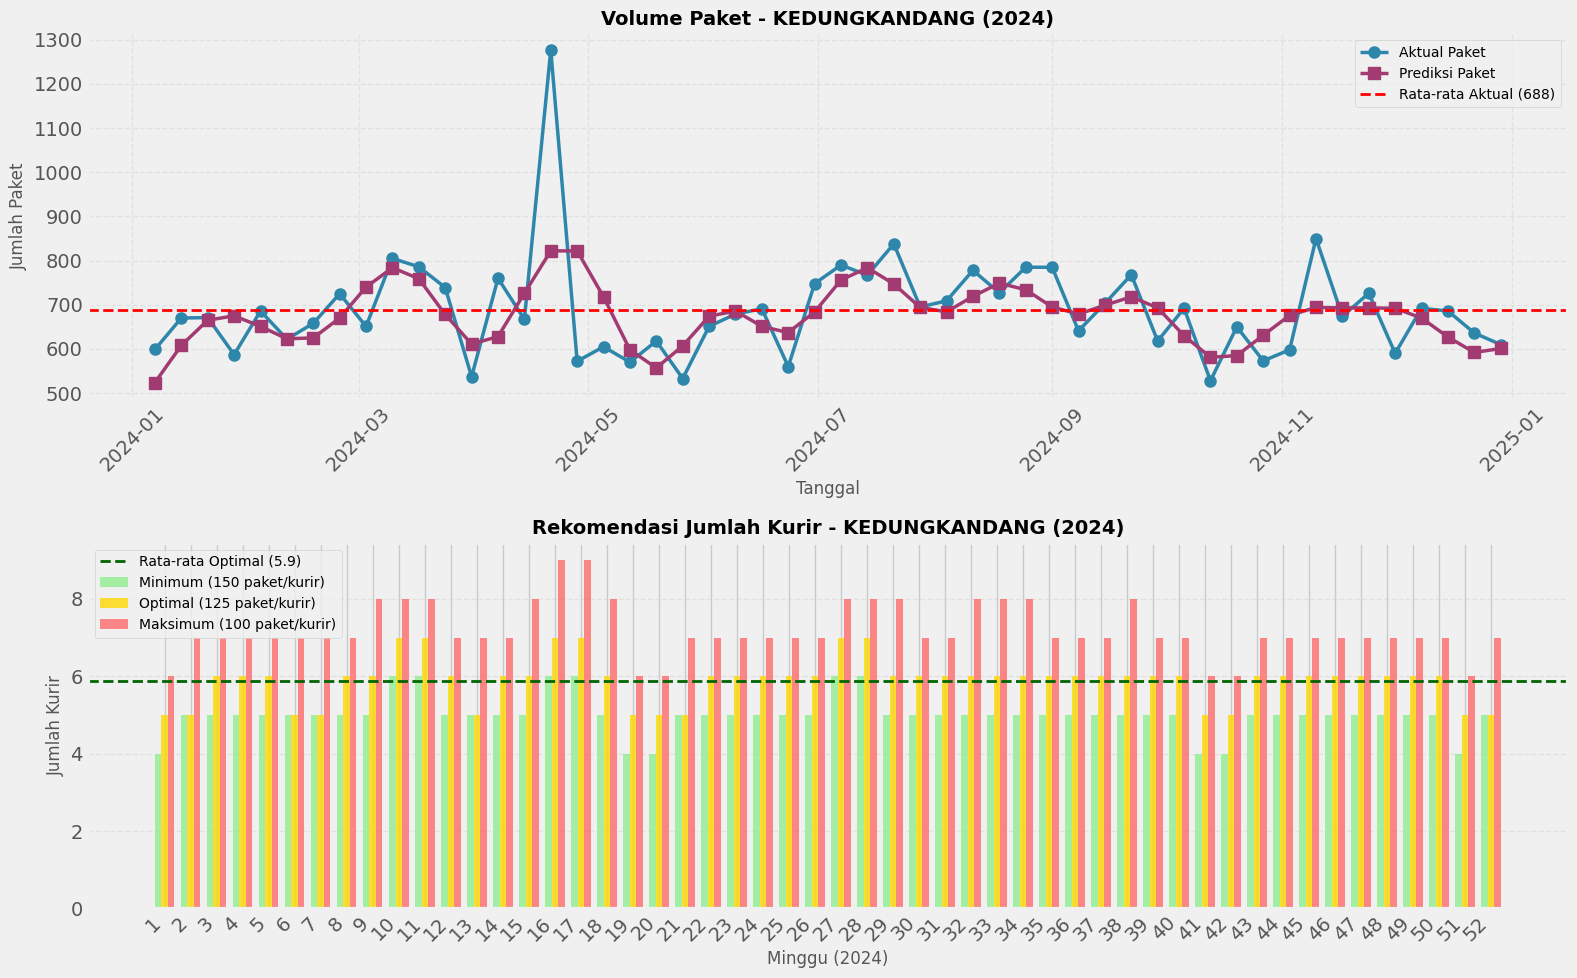


Kecamatan: KLOJEN


,Tanggal,Minggu_Ke,Prediksi_Paket,Aktual_Paket,Kurir_Minimum,Kurir_Optimal,Kurir_Maksimum,Selisih_Paket,Status
0,2024-01-07,1,1919,2212,13,16,20,293,Perlu Perhatian
1,2024-01-14,2,2484,2441,17,20,25,-43,Sesuai
2,2024-01-21,3,2807,2620,19,23,29,-187,Sesuai
3,2024-01-28,4,2822,2441,19,23,29,-381,Perlu Perhatian
4,2024-02-04,5,2658,2953,18,22,27,295,Sesuai
5,2024-02-11,6,2446,2140,17,20,25,-306,Perlu Perhatian
6,2024-02-18,7,2251,2383,16,19,23,132,Sesuai
7,2024-02-25,8,2165,2438,15,18,22,273,Perlu Perhatian
8,2024-03-03,9,2342,1884,16,19,24,-458,Perlu Perhatian
9,2024-03-10,10,2824,2451,19,23,29,-373,Perlu Perhatian



Ringkasan Rekomendasi Kurir - KLOJEN (2024):
   Rata-rata Prediksi Paket: 2054 paket/minggu
   Rata-rata Aktual Paket: 2063 paket/minggu
   ─────────────────────────────────────────────────
   Rekomendasi Kurir Minimum: 14.2 kurir (beban 150 paket/kurir)
   Rekomendasi Kurir Optimal: 17.0 kurir (beban 125 paket/kurir)
   Rekomendasi Kurir Maksimum: 21.1 kurir (beban 100 paket/kurir)
   ─────────────────────────────────────────────────
   REKOMENDASI: Sediakan 17 kurir tetap
   Untuk minggu sibuk, tambahkan 19 kurir cadangan


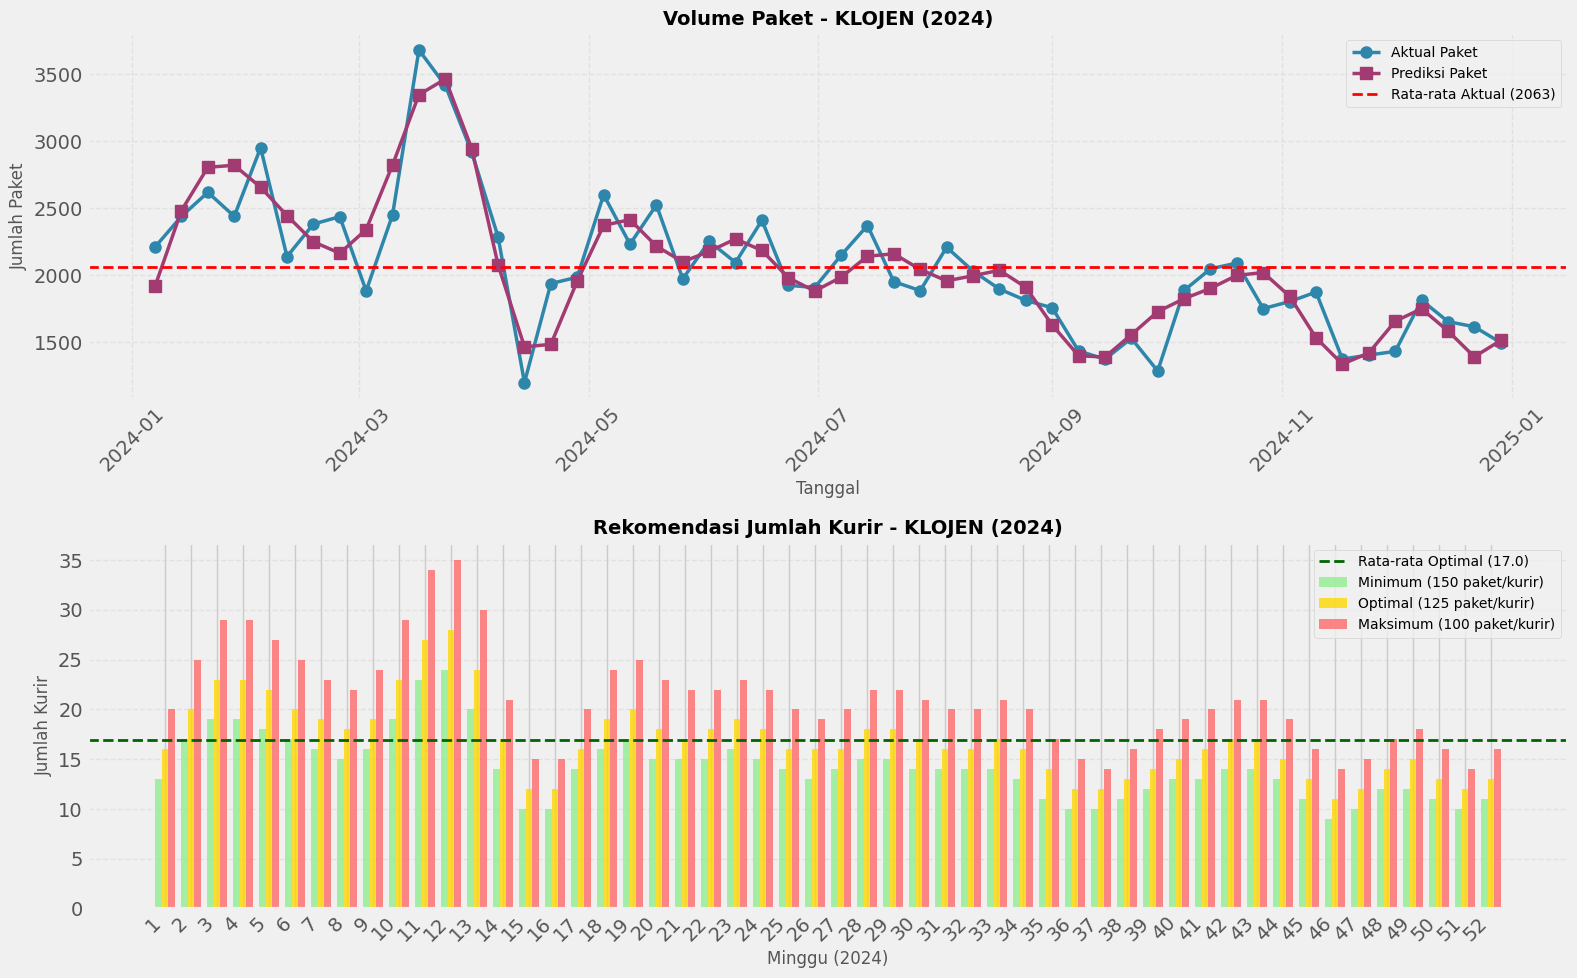


Kecamatan: LOWOKWARU


,Tanggal,Minggu_Ke,Prediksi_Paket,Aktual_Paket,Kurir_Minimum,Kurir_Optimal,Kurir_Maksimum,Selisih_Paket,Status
0,2024-01-07,1,833,911,6,7,9,78,Sesuai
1,2024-01-14,2,1058,1016,8,9,11,-42,Sesuai
2,2024-01-21,3,1189,1023,8,10,12,-166,Perlu Perhatian
3,2024-01-28,4,1147,1479,8,10,12,332,Perlu Perhatian
4,2024-02-04,5,1015,997,7,9,11,-18,Sesuai
5,2024-02-11,6,949,881,7,8,10,-68,Sesuai
6,2024-02-18,7,1018,1147,7,9,11,129,Perlu Perhatian
7,2024-02-25,8,1162,1221,8,10,12,59,Sesuai
8,2024-03-03,9,1267,1037,9,11,13,-230,Perlu Perhatian
9,2024-03-10,10,1277,1302,9,11,13,25,Sesuai



Ringkasan Rekomendasi Kurir - LOWOKWARU (2024):
   Rata-rata Prediksi Paket: 1139 paket/minggu
   Rata-rata Aktual Paket: 1155 paket/minggu
   ─────────────────────────────────────────────────
   Rekomendasi Kurir Minimum: 8.1 kurir (beban 150 paket/kurir)
   Rekomendasi Kurir Optimal: 9.6 kurir (beban 125 paket/kurir)
   Rekomendasi Kurir Maksimum: 11.9 kurir (beban 100 paket/kurir)
   ─────────────────────────────────────────────────
   REKOMENDASI: Sediakan 10 kurir tetap
   Untuk minggu sibuk, tambahkan 6 kurir cadangan


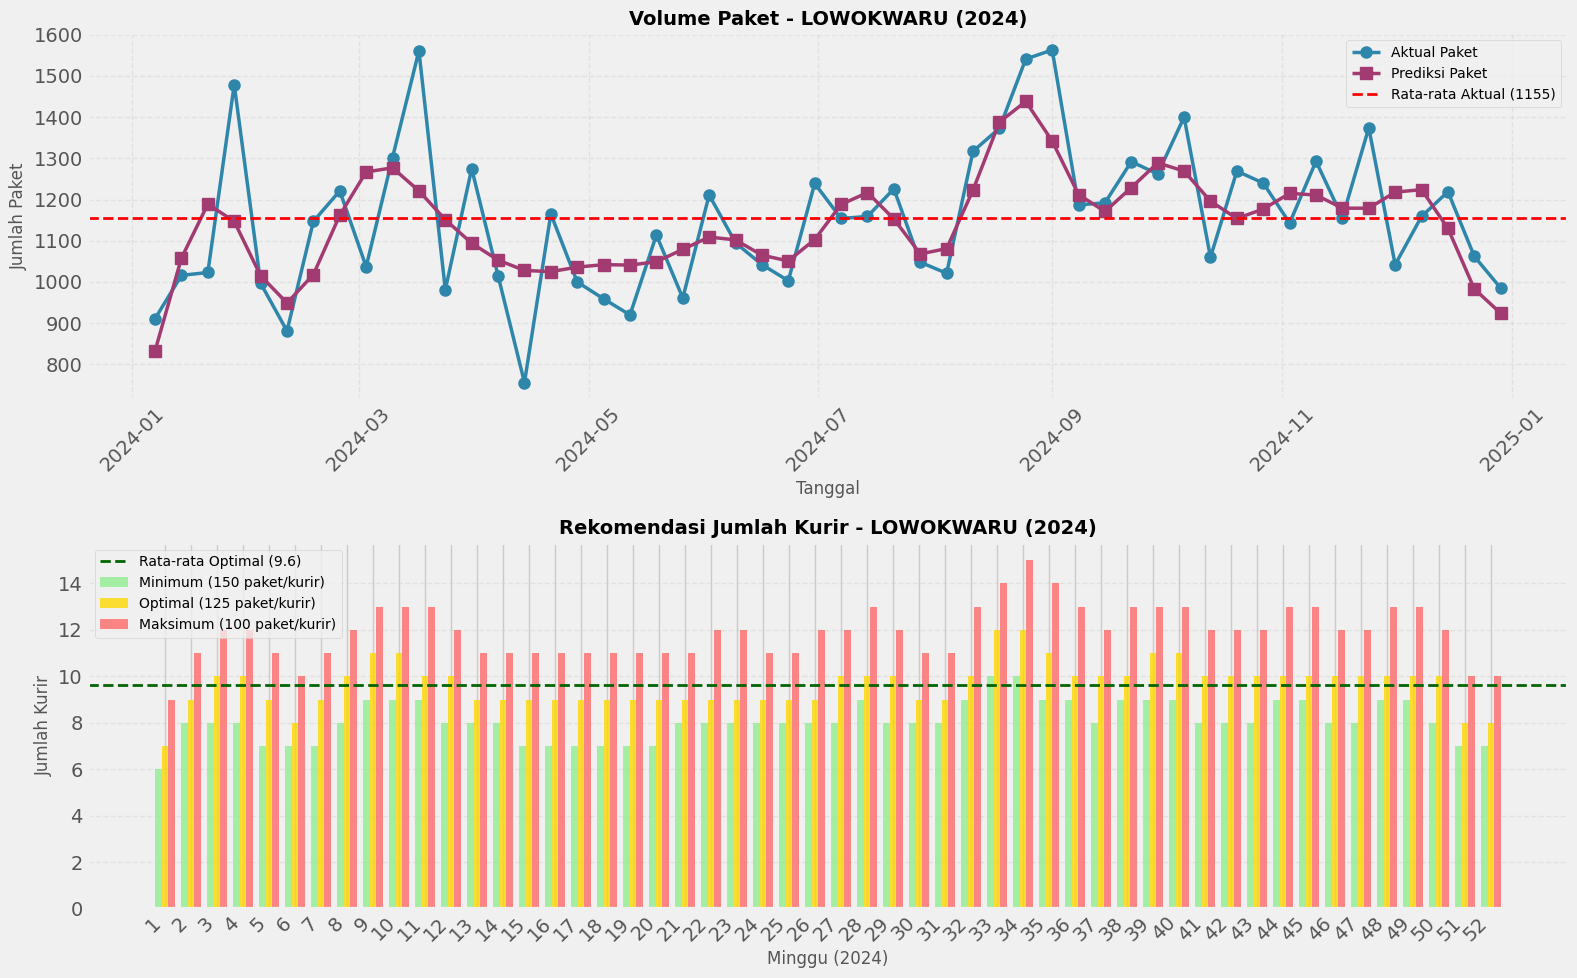


Kecamatan: SUKUN


,Tanggal,Minggu_Ke,Prediksi_Paket,Aktual_Paket,Kurir_Minimum,Kurir_Optimal,Kurir_Maksimum,Selisih_Paket,Status
0,2024-01-07,1,639,562,5,6,7,-77,Perlu Perhatian
1,2024-01-14,2,643,658,5,6,7,15,Sesuai
2,2024-01-21,3,647,649,5,6,7,2,Sesuai
3,2024-01-28,4,648,662,5,6,7,14,Sesuai
4,2024-02-04,5,644,644,5,6,7,0,Sesuai
5,2024-02-11,6,641,605,5,6,7,-36,Sesuai
6,2024-02-18,7,643,629,5,6,7,-14,Sesuai
7,2024-02-25,8,648,658,5,6,7,10,Sesuai
8,2024-03-03,9,650,581,5,6,7,-69,Perlu Perhatian
9,2024-03-10,10,646,702,5,6,7,56,Sesuai



Ringkasan Rekomendasi Kurir - SUKUN (2024):
   Rata-rata Prediksi Paket: 650 paket/minggu
   Rata-rata Aktual Paket: 752 paket/minggu
   ─────────────────────────────────────────────────
   Rekomendasi Kurir Minimum: 5.0 kurir (beban 150 paket/kurir)
   Rekomendasi Kurir Optimal: 6.0 kurir (beban 125 paket/kurir)
   Rekomendasi Kurir Maksimum: 7.0 kurir (beban 100 paket/kurir)
   ─────────────────────────────────────────────────
   REKOMENDASI: Sediakan 6 kurir tetap
   Untuk minggu sibuk, tambahkan 1 kurir cadangan


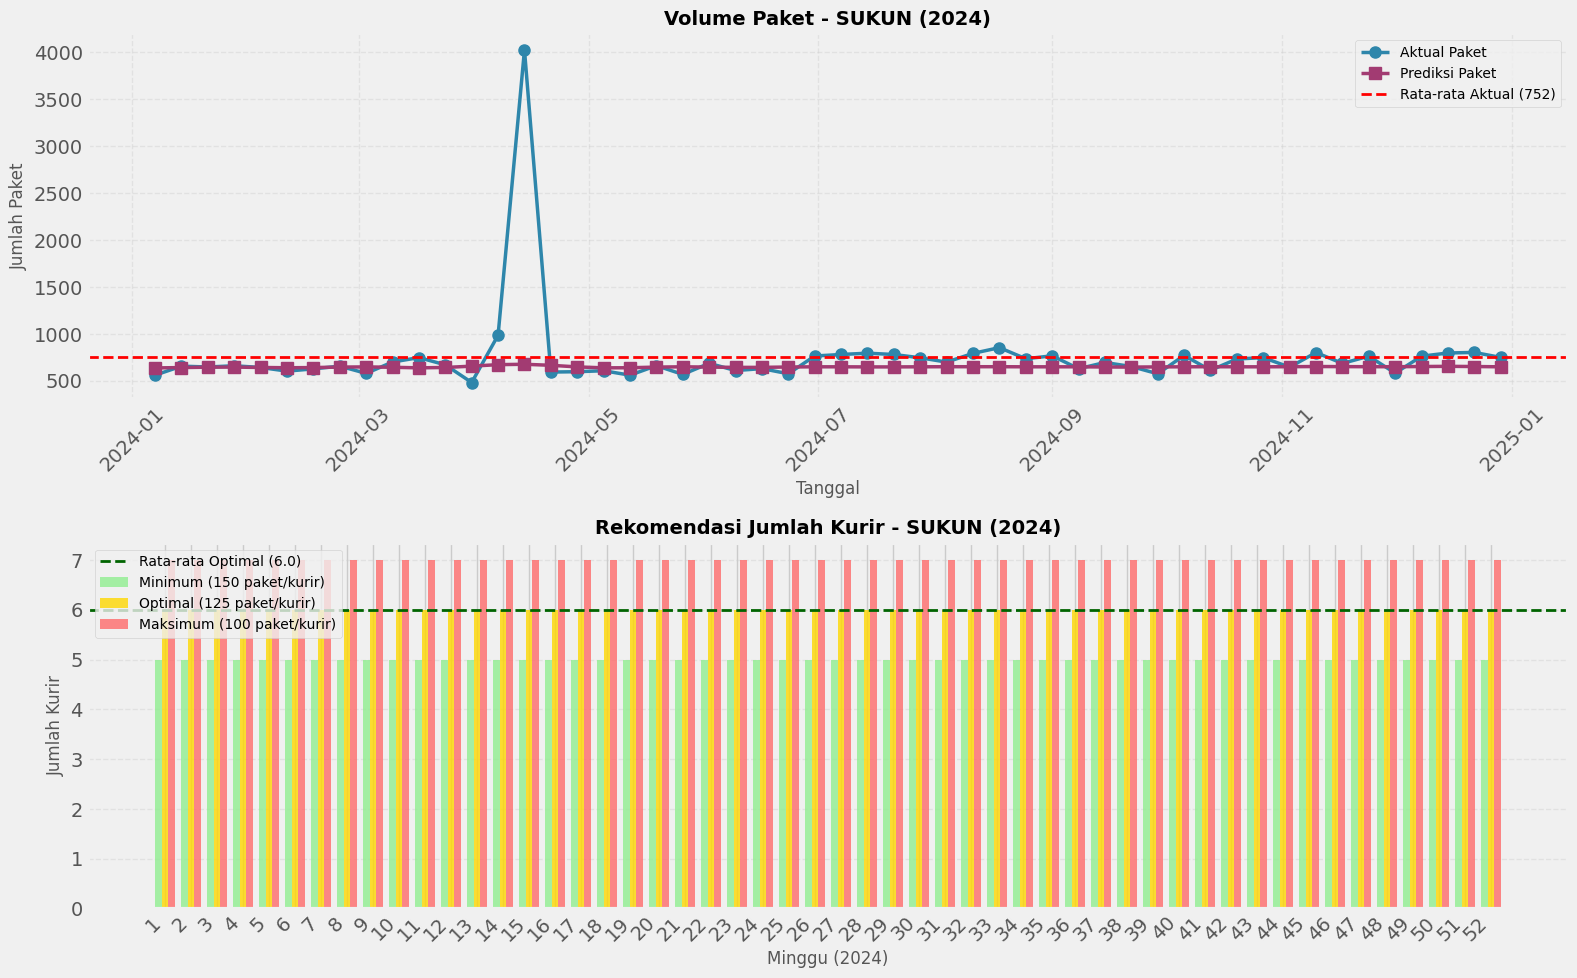

In [18]:
# Rekomendasi Jumlah Kurir berdasarkan Prediksi 2024
print("Menghitung Rekomendasi Jumlah Kurir untuk tahun 2024")
print("Asumsi: 1 kurir dapat menangani 100-150 paket per minggu\n")

# Definisikan kapasitas kurir
KAPASITAS_KURIR_MIN = 100  # paket per minggu per kurir (beban tinggi)
KAPASITAS_KURIR_MAX = 150  # paket per minggu per kurir (beban normal)

for kecamatan in unique_kecamatan:
    print(f"\n{'='*90}")
    print(f"Kecamatan: {kecamatan}")
    print(f"{'='*90}")
    
    # Ambil data dari hasil prediksi
    result = predictions_results[kecamatan]
    test_data = result['test'].copy()
    test_pred = result['test_predictions'].copy()
    
    # Filter hanya untuk tahun 2024
    test_data_2024 = test_data[test_data['Tgl_Kirim'].dt.year == 2024].copy()
    test_pred_2024 = test_pred[test_pred['ds'].dt.year == 2024].copy()
    
    # Buat tabel rekomendasi kurir
    kurir_recommendation = pd.DataFrame({
        'Tanggal': test_data_2024['Tgl_Kirim'].values,
        'Minggu_Ke': test_data_2024['minggu_ke'].values,
        'Prediksi_Paket': test_pred_2024['yhat'].round(0).astype(int).values,
        'Aktual_Paket': test_data_2024['total paket'].values,
        'Kurir_Minimum': np.ceil(test_pred_2024['yhat'] / KAPASITAS_KURIR_MAX).astype(int).values,
        'Kurir_Optimal': np.ceil(test_pred_2024['yhat'] / 125).astype(int).values,  # rata-rata 125
        'Kurir_Maksimum': np.ceil(test_pred_2024['yhat'] / KAPASITAS_KURIR_MIN).astype(int).values,
    })
    
    # Hitung selisih prediksi vs aktual
    kurir_recommendation['Selisih_Paket'] = (kurir_recommendation['Aktual_Paket'] - 
                                              kurir_recommendation['Prediksi_Paket'])
    
    # Rekomendasi status
    def get_status(pred, actual):
        diff_pct = abs(actual - pred) / actual * 100
        if diff_pct < 10:
            return "Sesuai"
        elif diff_pct < 30:
            return "Perlu Perhatian"
        else:
            return "Kritis"
    
    kurir_recommendation['Status'] = kurir_recommendation.apply(
        lambda row: get_status(row['Prediksi_Paket'], row['Aktual_Paket']), axis=1
    )
    
    # Tampilkan tabel
    display(kurir_recommendation)
    
    # Statistik ringkasan
    print(f"\nRingkasan Rekomendasi Kurir - {kecamatan} (2024):")
    print(f"   Rata-rata Prediksi Paket: {kurir_recommendation['Prediksi_Paket'].mean():.0f} paket/minggu")
    print(f"   Rata-rata Aktual Paket: {kurir_recommendation['Aktual_Paket'].mean():.0f} paket/minggu")
    print(f"   ─────────────────────────────────────────────────")
    print(f"   Rekomendasi Kurir Minimum: {kurir_recommendation['Kurir_Minimum'].mean():.1f} kurir (beban 150 paket/kurir)")
    print(f"   Rekomendasi Kurir Optimal: {kurir_recommendation['Kurir_Optimal'].mean():.1f} kurir (beban 125 paket/kurir)")
    print(f"   Rekomendasi Kurir Maksimum: {kurir_recommendation['Kurir_Maksimum'].mean():.1f} kurir (beban 100 paket/kurir)")
    print(f"   ─────────────────────────────────────────────────")
    print(f"   REKOMENDASI: Sediakan {int(np.ceil(kurir_recommendation['Kurir_Optimal'].mean()))} kurir tetap")
    print(f"   Untuk minggu sibuk, tambahkan {int(np.ceil(kurir_recommendation['Kurir_Maksimum'].max() - kurir_recommendation['Kurir_Optimal'].mean()))} kurir cadangan")
    
    # Visualisasi kebutuhan kurir
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
    
    # Plot 1: Prediksi Paket vs Aktual
    ax1.plot(kurir_recommendation['Tanggal'], kurir_recommendation['Aktual_Paket'], 
             marker='o', label='Aktual Paket', linewidth=2.5, markersize=8, color='#2E86AB')
    ax1.plot(kurir_recommendation['Tanggal'], kurir_recommendation['Prediksi_Paket'], 
             marker='s', label='Prediksi Paket', linewidth=2.5, markersize=8, color='#A23B72')
    ax1.axhline(y=kurir_recommendation['Aktual_Paket'].mean(), color='red', 
                linestyle='--', label=f'Rata-rata Aktual ({kurir_recommendation["Aktual_Paket"].mean():.0f})', linewidth=2)
    ax1.set_title(f'Volume Paket - {kecamatan} (2024)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Tanggal', fontsize=12)
    ax1.set_ylabel('Jumlah Paket', fontsize=12)
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.4, linestyle='--')
    ax1.tick_params(axis='x', rotation=45)
    
    # Plot 2: Rekomendasi Kurir
    x_pos = range(len(kurir_recommendation))
    width = 0.25
    
    ax2.bar([x - width for x in x_pos], kurir_recommendation['Kurir_Minimum'], 
            width, label='Minimum (150 paket/kurir)', color='#90EE90', alpha=0.8)
    ax2.bar(x_pos, kurir_recommendation['Kurir_Optimal'], 
            width, label='Optimal (125 paket/kurir)', color='#FFD700', alpha=0.8)
    ax2.bar([x + width for x in x_pos], kurir_recommendation['Kurir_Maksimum'], 
            width, label='Maksimum (100 paket/kurir)', color='#FF6B6B', alpha=0.8)
    
    ax2.axhline(y=kurir_recommendation['Kurir_Optimal'].mean(), color='darkgreen', 
                linestyle='--', label=f'Rata-rata Optimal ({kurir_recommendation["Kurir_Optimal"].mean():.1f})', linewidth=2)
    
    ax2.set_title(f'Rekomendasi Jumlah Kurir - {kecamatan} (2024)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Minggu (2024)', fontsize=12)
    ax2.set_ylabel('Jumlah Kurir', fontsize=12)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(kurir_recommendation['Minggu_Ke'], rotation=45, ha='right')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.4, linestyle='--', axis='y')
    
    plt.tight_layout()
    plt.show()